TAOG (Time-Averaged Occupancy Grid) Analysis

🔄 Loading simulation data...
--- Stage 1: Reading LAMMPS Trajectory ---


/home/ram/software/miniconda3/lib/python3.12/site-packages/MDAnalysis/topology/LAMMPSParser.py:637: UserWarning: Guessed all Masses to 1.0
  warnings.warn('Guessed all Masses to 1.0')


DEBUG: Trajectory loaded with 30001 frames.
✅ Loaded trajectory with 30001 frames
 📊 48 diffusing Li atoms out of 3328 total

🔄 Calculating coordinates and displacement...
DEBUG: CoordinateProcessor instance created.
DEBUG: Calculating fractional coordinates and displacement...
DEBUG: Displacement calculation finished.
✅ Coordinate processing complete

🔄 Analyzing tracer properties from MSD...

--- Stage: Analyzing Tracer Properties (MSD) ---
-------------------------------------------
Calculating tracer diffusion and conductivity based on:
3 dimensional diffusion, and an ion with a charge of 1.0
Tracer diffusivity determined to be (in m^2/s): 1.0461e-12
Tracer conductivity determined to be (in Siemens/meter): 0.0049
-------------------------------------------
✅ Tracer property analysis complete

🔄 Analyzing vibrational properties...
Saved vibrational amplitudes: /media/ram/ext_disk/proj_mof/dp_data/test_package/analysis_output/vibrational_amplitudes.dat
Saved per-atom frequencies: /me

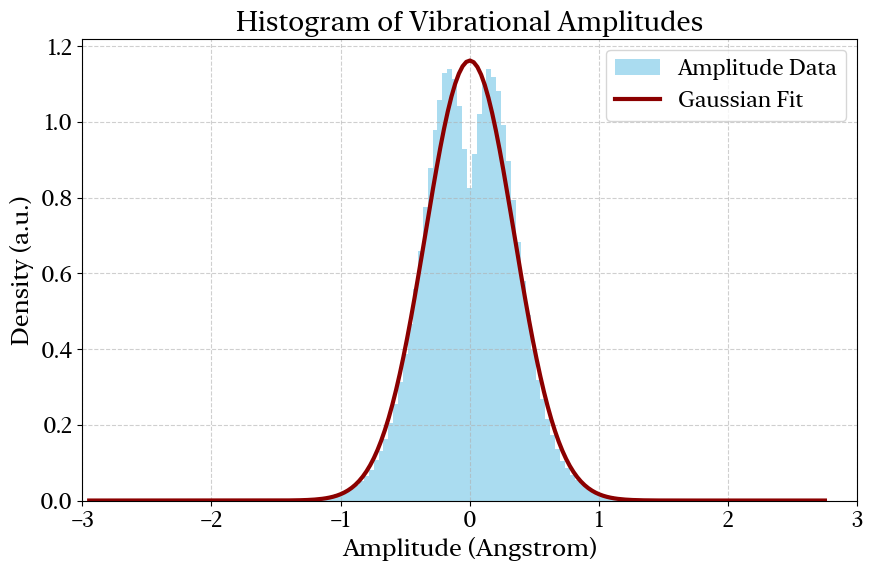

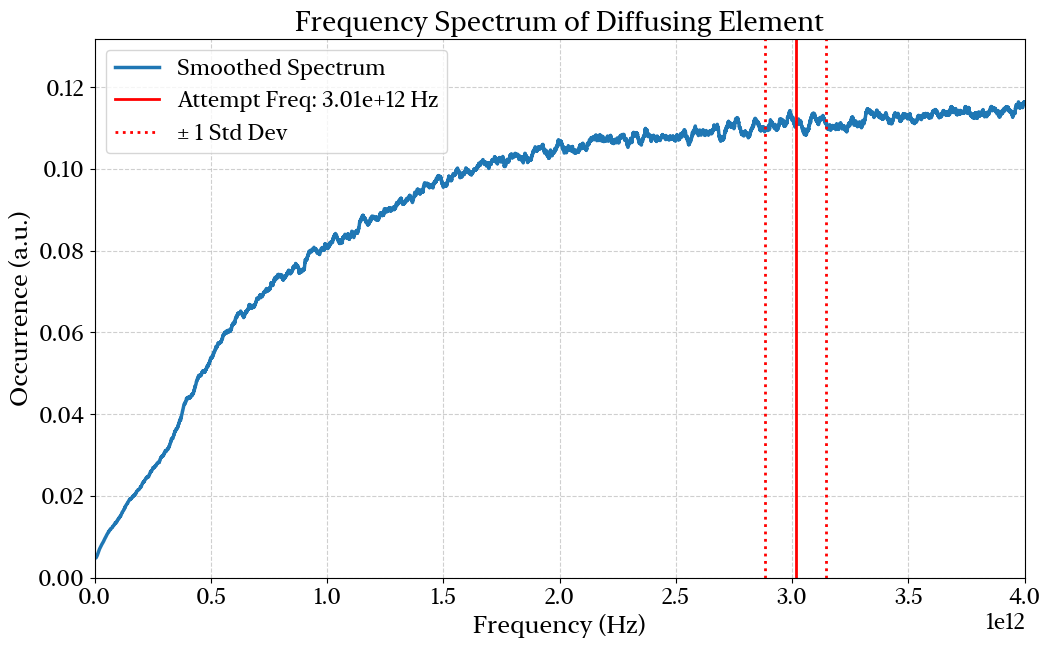

✅ Comprehensive vibrational analysis complete with all data saved

🔄 Discovering sites using TAOG method...
DEBUG: Building 100x100x100 occupancy grid...
DEBUG: Saved grid edges to /media/ram/ext_disk/proj_mof/dp_data/test_package/analysis_output/occupancy_grid_edges.npy
DEBUG: Using density threshold of 855.30 to find peaks.
DEBUG: Site radius statistics:
 Maximum site radius: 0.304 Å
 Mean site radius: 0.304 Å
 Individual site radii: [0.30417258 0.30417258 0.30417258 0.30417258 0.30417258 0.30417258
 0.30417258 0.30417258 0.30417258 0.30417258 0.30417258 0.30417258
 0.30417258 0.30417258 0.30417258 0.30417258 0.30417258 0.30417258
 0.30417258 0.30417258 0.30417258 0.30417258 0.30417258 0.30417258
 0.30417258 0.30417258 0.30417258 0.30417258 0.30417258 0.30417258
 0.30417258 0.30417258 0.30417258 0.30417258 0.30417258 0.30417258
 0.30417258 0.30417258 0.30417258 0.30417258 0.30417258 0.30417258
 0.30417258 0.30417258 0.30417258 0.30417258 0.30417258 0.30417258
 0.30417258 0.30417258 0

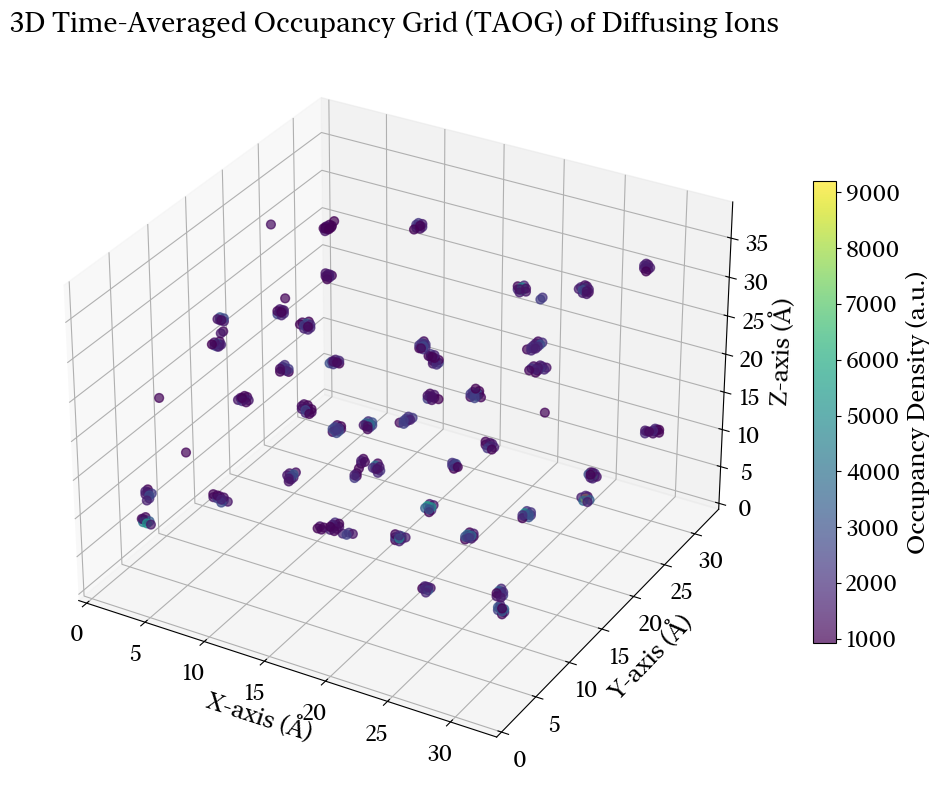

In [ ]:
# %%
import os
import sys
import traceback
import numpy as np

# Add package path
sys.path.append('/media/ram/ext_disk/proj_mof/dp_data/analysis/vf_ppr')

# Import all components from the package
from GPhIon import (
    load_simulation_data,
    CoordinateProcessor,
    TracerPropertyAnalyzer,
    VibrationAnalyzer,
    AmorphousSiteFinder,
    JumpAnalyzer,
    JumpDiffusivityAnalyzer,
    CollectiveJumpAnalyzer,
    RDFAnalyzer,
    plot_taog_density,
    VanHoveAnalyzer,
    MigrationPathwayPlotter,
    ActivationEnergyAnalyzer,
    ConnectivityPlotter,
    CollectivePlotter,
    DisplacementPlotter,
    VanHovePlotter
)

# %%
print("=" * 80)
print("TAOG (Time-Averaged Occupancy Grid) Analysis")
print("=" * 80)

# --- 1. Define Parameters ---
project_folder = '/media/ram/ext_disk/proj_mof/dp_data/test_package'
temperature = 450.0
dump_filename = 'pure_450.lammpstrj'
dump_filepath = os.path.join(project_folder, dump_filename)
type_to_element = {1: 'S', 2: 'F', 3: 'O', 4: 'N', 5: 'C', 6: 'Li', 7: 'Co', 8: 'H'}
diffusing_element = 'Li'
timestep_ps = 0.1  # Picosecond timestep 450:0.1, 400: 2.0
density_grid_resolution = 100
output_data_path = os.path.join(project_folder, "analysis_output")
diffusion_dimensionality = 3
ion_charge_z = 1.0
experimental_coll_dist = 6.0
experimental_coll_steps = None

# Ensure output directory exists
os.makedirs(output_data_path, exist_ok=True)

if not os.path.exists(dump_filepath):
    raise FileNotFoundError(f"CRITICAL ERROR: Trajectory file not found at '{dump_filepath}'")

# --- 2. Load Trajectory Data ---
print("\n🔄 Loading simulation data...")
sim_data_obj = load_simulation_data(
    dump_file=dump_filepath,
    type_to_element=type_to_element,
    diff_elem=diffusing_element,
    dt_ps=timestep_ps,
    temperature=temperature
)
print(f"✅ Loaded trajectory with {sim_data_obj.nr_steps} frames")
print(f" 📊 {sim_data_obj.nr_diffusing} diffusing {diffusing_element} atoms out of {sim_data_obj.nr_atoms} total")

# --- 3. Calculate Fractional Coordinates and Displacement ---
print("\n🔄 Calculating coordinates and displacement...")
coord_processor = CoordinateProcessor()
sim_data_obj = coord_processor.frac_and_disp(sim_data_obj)
print("✅ Coordinate processing complete")

# %%
# --- 4. Calculate Tracer Properties (from MSD) ---
print("\n🔄 Analyzing tracer properties from MSD...")
tracer_analyzer = TracerPropertyAnalyzer(sim_data_obj)
tracer_results = tracer_analyzer.calculate_tracer_properties(
    diffusion_dim=diffusion_dimensionality,
    z_ion=ion_charge_z
)
print("✅ Tracer property analysis complete")

# --- 5. COMPREHENSIVE Vibrational Properties Analysis ---
print("\n🔄 Analyzing vibrational properties...")
vib_analyzer = VibrationAnalyzer()

# Run complete vibration analysis with data saving
attempt_freq, vibration_amp, std_freq = vib_analyzer.vibration_properties(
    sim_data_obj,
    show_pics=False,
    save_data=True,
    output_dir=output_data_path
)

# Get detailed vibration data
vib_data = vib_analyzer.get_vibration_data_only(sim_data_obj)
max_vib_amplitude = np.max(np.abs(vib_data['amplitude_data']))

# Generate additional custom plots
vib_analyzer.plot_amplitude_histogram_only(
    vib_data,
    bins=150,
    colors={'hist': 'skyblue', 'fit': 'darkred'},
    xlim=(-3.0, 3.0),
    output_file=f"{output_data_path}/custom_amplitude_hist.png"
)

vib_analyzer.plot_frequency_spectrum_only(
    vib_data,
    xlim=(0, 4.0e12),
    smooth_window=75,
    output_file=f"{output_data_path}/custom_frequency_spectrum.png"
)

# Store results in sim_data object
sim_data_obj.attempt_freq = attempt_freq
sim_data_obj.vibration_amp = vibration_amp
sim_data_obj.std_attempt_freq = std_freq
print("✅ Comprehensive vibrational analysis complete with all data saved")

# %%
# --- 6. Site Discovery with Radius Calculation ---
print("\n🔄 Discovering sites using TAOG method...")
site_finder = AmorphousSiteFinder(
    sim_data=sim_data_obj,
    grid_resolution=density_grid_resolution,
    save_path=output_data_path
)

# Build the density grid
density_grid, edges = site_finder._build_occupancy_grid()

# Get peaks with labels
labeled_peaks, num_features, peak_indices = site_finder._find_grid_peaks(
    density_grid, return_labels=True)

# Convert to Cartesian coordinates
discovered_sites_cart = site_finder._convert_indices_to_coords(peak_indices, edges)

if discovered_sites_cart.size == 0:
    raise RuntimeError("❌ No sites were discovered. Check your parameters.")

# Calculate site radii
site_radii = site_finder.get_site_radii(
    labeled_peaks, num_features, edges, discovered_sites_cart, pct=95)

max_site_radius = site_radii.max()
mean_site_radius = site_radii.mean()

print(f"DEBUG: Site radius statistics:")
print(f" Maximum site radius: {max_site_radius:.3f} Å")
print(f" Mean site radius: {mean_site_radius:.3f} Å")
print(f" Individual site radii: {site_radii}")

# Save the results
sites_filepath = os.path.join(output_data_path, 'discovered_sites_cart.npy')
radii_filepath = os.path.join(output_data_path, 'site_radii.npy')
np.save(sites_filepath, discovered_sites_cart)
np.save(radii_filepath, site_radii)

print(f"✅ Site discovery complete: {len(discovered_sites_cart)} sites found")
print(f"📏 Saved site coordinates to {sites_filepath}")
print(f"📏 Saved site radii to {radii_filepath}")

# --- 7. Visualize TAOG Density Grid ---
print("\n🔄 Generating TAOG density visualization...")
try:
    plot_output = os.path.join(output_data_path, 'taog_density_plot.png')
    plot_taog_density(density_grid, edges, threshold_ratio=0.1, output_file=plot_output)
    print("✅ TAOG visualization saved")
except Exception as e:
    print(f"⚠️ Could not generate TAOG visualization: {e}")

# # %%
# # --- 8. Create Diffusing Atoms Group and Run Jump Analysis ---
# print("\n🔄 Creating diffusing atoms group...")
# diffusing_atoms_group = sim_data_obj.universe.select_atoms(f"element {diffusing_element}")
# print(f"✅ Selected {len(diffusing_atoms_group)} {diffusing_element} atoms for jump analysis")

# print("\n🔄 Analyzing jumps between sites...")
# jump_analysis = SiteAnalyzerMDA(
#     diffusing_atom_group=diffusing_atoms_group,
#     site_coordinates_cart=discovered_sites_cart
# )

# # Set the maximum site radius for jump detection
# jump_analysis.site_radius = max_site_radius
# print(f"Setting site radius to maximum: {max_site_radius:.4f} Å")

# jump_analysis.run()
# num_jumps_found = len(jump_analysis.results.all_trans) if hasattr(jump_analysis.results, 'all_trans') else 0
# print(f"✅ Jump analysis complete: {num_jumps_found} jumps detected")

# # --- 9. Calculate Jump Diffusivity ---
# print("\n🔄 Calculating jump diffusivity...")
# jump_diffusivity_val = 0.0
# if num_jumps_found > 0:
#     diffusivity_analyzer = JumpDiffusivityAnalyzer(
#         sim_data=sim_data_obj,
#         jump_analysis_results=jump_analysis.results,
#         site_coordinates_cart=discovered_sites_cart
#     )
    
#     jump_diffusivity_val = diffusivity_analyzer.calculate_jump_properties(
#         show_plot=True,
#         save_data=True,
#         output_dir=output_data_path
#     )
    
#     diffusivity_analyzer.save_jump_summary(jump_diffusivity_val, output_data_path)
#     print("✅ Jump diffusivity calculation complete with data saved")
# else:
#     print("⚠️ No jumps found - skipping jump diffusivity calculation")

# # --- 10. Analyze Collective Jumps ---
# print("\n🔄 Analyzing collective jump behavior...")
# collective_results = None
# if num_jumps_found > 0:
#     collective_analyzer = CollectiveJumpAnalyzer(
#         sim_data=sim_data_obj,
#         jump_analysis_results=jump_analysis.results,
#         site_coordinates_cart=discovered_sites_cart,
#         coll_dist=experimental_coll_dist,
#         coll_steps_manual=experimental_coll_steps
#     )
    
#     collective_results = collective_analyzer.analyze()
#     print("✅ Collective jump analysis complete")
# else:
#     print("⚠️ No jumps found - skipping collective jump analysis")

# # --- 11. COMPREHENSIVE Migration Pathway Analysis ---
# print("\n🛤️ Analyzing comprehensive migration pathways...")
# if num_jumps_found > 0:
#     migration_plotter = MigrationPathwayPlotter()
    
#     # Generate all migration pathway analyses in one comprehensive call
#     migration_analysis = migration_plotter.plot_comprehensive_migration_analysis(
#         sites_cart=discovered_sites_cart,
#         jump_data=jump_analysis.results.all_trans,
#         min_probability=0.001,
#         output_dir=output_data_path
#     )
    
#     print("✅ Comprehensive migration pathway analysis complete!")
    
#     # Display key results
#     prob_results = migration_analysis['migration_probabilities']
#     pathway_results = migration_analysis['pathway_analysis']
#     print(f"\n🛤️ MIGRATION PATHWAY RESULTS:")
#     print(f" Total migration pathways: {pathway_results['total_edges']}")
#     print(f" Most active source site: Site {pathway_results['most_central_out'][0]+1}")
#     print(f" Most active sink site: Site {pathway_results['most_central_in'][0]+1}")
#     print(f" Key bridge site: Site {pathway_results['most_between'][0]+1}")
    
#     if pathway_results['high_probability_edges']:
#         top_pathway = pathway_results['high_probability_edges'][0]
#         print(f" Highest probability pathway: Site {top_pathway[0]+1} → Site {top_pathway[1]+1} ({top_pathway[2]:.4f})")
# else:
#     print("⚠️ No jumps found - skipping migration pathway analysis")

# # --- 12. COMPREHENSIVE Activation Energy Analysis ---
# print("\n⚡ Calculating comprehensive activation energies...")
# if num_jumps_found > 0:
#     sim_data_obj.temperature = temperature  # K
#     activation_analyzer = ActivationEnergyAnalyzer(sim_data_obj)
    
#     # Overall activation energy
#     total_time = sim_data_obj.total_time
#     effective_freq = num_jumps_found / (sim_data_obj.nr_diffusing * total_time)
    
#     print(f"Validation check:")
#     print(f" Effective frequency: {effective_freq:.2e} Hz")
#     print(f" Attempt frequency: {sim_data_obj.attempt_freq:.2e} Hz")
#     print(f" Frequency ratio: {effective_freq/sim_data_obj.attempt_freq:.4f}")
    
#     if effective_freq/sim_data_obj.attempt_freq < 1.0:
#         try:
#             overall_activation = activation_analyzer.calculate_activation_energy_from_frequencies(
#                 effective_jump_freq=effective_freq,
#                 attempt_freq=sim_data_obj.attempt_freq,
#                 temperature=sim_data_obj.temperature
#             )
#             print(f"✅ Overall Activation Energy: {overall_activation['activation_energy_eV']:.3f} eV")
#         except Exception as e:
#             print(f"⚠️ Could not calculate overall activation energy: {e}")
    
#     # Site-specific with occupancy corrections - FIXED COLORBAR ERROR
#     try:
#         site_energies = activation_analyzer.calculate_activation_energies_with_occupancy(
#             jump_analysis_results=jump_analysis,
#             sites_cart=discovered_sites_cart,
#             temperature=sim_data_obj.temperature
#         )
        
#         if site_energies:
#             # Create a figure and axes for the comparison plot to fix colorbar error
#             import matplotlib.pyplot as plt
#             fig, ax = plt.subplots(figsize=(10, 6))
            
#             # Modified activation energy comparison with explicit axes
#             activation_analyzer.compare_activation_energies(
#                 site_energies,
#                 output_file=f"{output_data_path}/activation_energies_comparison.png"
#             )
#             plt.close()  # Close the figure to prevent interference

#             activation_analyzer.generate_activation_energy_report(
#                 site_energies,
#                 output_file=f"{output_data_path}/activation_energy_report.txt"
#             )
            
#             print(f"✅ Site-specific activation energies calculated for {len(site_energies)} jump types")
#     except Exception as e:
#         print(f"⚠️ Site-specific activation energy calculation failed: {e}")
# else:
#     print("⚠️ No jumps found - skipping activation energy analysis")

# # %%
# # --- 13. CONSOLIDATED Data Saving ---
# print("\n💾 Saving all occupancy and jump data...")
# jump_output_path = f"{output_data_path}/jump_output"
# os.makedirs(jump_output_path, exist_ok=True)

# if num_jumps_found > 0:
#     # Save all data files with proper formatting
#     site_occupancy_data = np.column_stack([
#         np.arange(len(jump_analysis.results.site_occupancies)),
#         jump_analysis.results.site_occupancies
#     ])
#     np.savetxt(f'{jump_output_path}/site_occupancies.txt',
#                site_occupancy_data,
#                header='Site_ID Average_Occupancy(atoms)',
#                fmt='%d %.6f')
    
#     occupancy_factor_data = np.column_stack([
#         np.arange(len(jump_analysis.results.average_occupancy_factors)),
#         jump_analysis.results.average_occupancy_factors
#     ])
#     np.savetxt(f'{jump_output_path}/occupancy_factors.txt',
#                occupancy_factor_data,
#                header='Site_ID Occupancy_Factor',
#                fmt='%d %.6f')
    
#     # Save residence time statistics
#     with open(f'{jump_output_path}/residence_time_stats.txt', 'w') as f:
#         f.write("Site_ID Mean_ResidenceTime(ps) Std_ResidenceTime Min_ResidenceTime Max_ResidenceTime Count\n")
#         for site_idx in range(jump_analysis.n_sites):
#             stats = jump_analysis.results.residence_time_stats[site_idx]
#             f.write(f"{site_idx} {stats['mean']:.6f} {stats['std']:.6f} "
#                    f"{stats['min']:.6f} {stats['max']:.6f} {stats['count']}\n")
    
#     # Save jump events
#     np.savetxt(f'{jump_output_path}/jump_events.txt', jump_analysis.results.all_trans,
#                header='AtomIndex FromSite ToSite Time(ps)', fmt='%d %d %d %.6f')
    
#     # Save jump-specific occupancy factors
#     occupancy_factors = jump_analysis.get_jump_specific_occupancy_factors()
#     with open(f'{jump_output_path}/jump_occupancy_factors.txt', 'w') as f:
#         f.write("Jump_Type Occupancy_Factor\n")
#         for jump_type, factor in occupancy_factors.items():
#             f.write(f"{jump_type} {factor:.6f}\n")
    
#     # Save comprehensive summary
#     with open(f'{jump_output_path}/occupancy_summary.txt', 'w') as f:
#         f.write("SITE OCCUPANCY SUMMARY\n")
#         f.write("="*50 + "\n\n")
#         f.write(f"Total Sites: {jump_analysis.n_sites}\n")
#         f.write(f"Total Diffusing Atoms: {len(jump_analysis._ag)}\n")
#         f.write(f"Total Jumps Detected: {len(jump_analysis.results.all_trans)}\n")
#         f.write(f"Average Site Occupancy: {np.mean(jump_analysis.results.site_occupancies):.3f} atoms\n")
#         f.write(f"Average Occupancy Factor: {np.mean(jump_analysis.results.average_occupancy_factors):.4f}\n\n")
#         f.write("DETAILED SITE INFORMATION:\n")
#         f.write("-" * 30 + "\n")
#         f.write(f"{'Site_ID':<8} {'Avg_Occ':<10} {'Occ_Factor':<12} {'Residence_Events':<15}\n")
#         f.write("-" * 50 + "\n")
#         for site_idx in range(jump_analysis.n_sites):
#             avg_occ = jump_analysis.results.site_occupancies[site_idx]
#             occ_factor = jump_analysis.results.average_occupancy_factors[site_idx]
#             res_events = jump_analysis.results.residence_time_stats[site_idx]['count']
#             f.write(f"{site_idx:<8} {avg_occ:<10.3f} {occ_factor:<12.6f} {res_events:<15}\n")

# print("✅ All data saved with proper formatting!")

# # --- 14. CONSOLIDATED Collective Analysis Plotting ---
# print("\n📊 Generating all collective analysis plots...")
# if collective_results:
#     coll_plotter = CollectivePlotter()
#     coll_plotter.plot_all_collective_analyses(
#         collective_results,
#         jump_analysis.results.all_trans,
#         timestep=sim_data_obj.time_step,
#         output_dir=output_data_path
#     )
#     print("✅ All collective plots generated!")
# else:
#     print("⚠️ No collective results available - skipping collective plotting")

# # --- 15. Additional Comprehensive Analyses ---
# print("\n🔄 Running additional comprehensive analyses...")

# # Connectivity Analysis
# if num_jumps_found > 0:
#     conn_plotter = ConnectivityPlotter()
#     conn_plotter.plot_3d_site_connectivity(
#         sites_cart=discovered_sites_cart,
#         jump_data=jump_analysis.results.all_trans,
#         min_jumps=1,
#         edge_width_scale=8,
#         node_size=150,
#         show_site_labels=True,
#         colormap='plasma',
#         output_file=f"{output_data_path}/3d_site_connectivity.png"
#     )

# # Displacement Analysis
# disp_plotter = DisplacementPlotter()
# disp_plotter.plot_individual_displacements(
#     sim_data_obj,
#     timestep=sim_data_obj.time_step,
#     max_atoms=50,
#     output_file=f"{output_data_path}/individual_displacements.png"
# )

# disp_plotter.plot_displacement_histogram(
#     sim_data_obj,
#     bins=60,
#     output_file=f"{output_data_path}/displacement_histogram.png"
# )




🔄 Creating diffusing atoms group...
✅ Selected 48 Li atoms for jump analysis

🔄 Analyzing jumps between sites...
Setting site radius to maximum: 0.3042 Å
Original frame interval: 0.1 ps
Calculated frame gap: 100.0
Redefined dt (new_dt): 0.001 ps
DEBUG: Calculated vibration_amp: 0.3045 Å
DEBUG: site_radius supplied externally: 0.3042 Å


  0%|          | 0/30001 [00:00<?, ?it/s]

DEBUG: Jump analysis complete with occupancy tracking
 Total jumps detected: 331
 Average site occupancies: [0.10019666 0.21245958 0.21822606 0.14719509 0.3731209  0.22969234
 0.19972668 0.10372988 0.07649745 0.31132296 0.07953068 0.25829139
 0.22109263 0.1378954  0.16146128 0.11899603 0.07759741 0.22972568
 0.23705876 0.2279924  0.20169328 0.25112496 0.17349422 0.18556048
 0.10136329 0.21409286 0.30605646 0.19502683 0.21165961 0.21259291
 0.40628646 0.1909603  0.08559715 0.33438885 0.19346022 0.17582747
 0.30075664 0.32262258 0.27502417 0.15479484 0.16756108 0.32575581
 0.4390187  0.17836072 0.11976267 0.24452518 0.35548815 0.14979501
 0.16296123 0.07123096 0.25295823 0.15946135 0.26205793 0.21755941
 0.13539549 0.16412786 0.43701877 0.2550915  0.57924736 0.28422386]
 Used timestep (normalized): 0.001 ps
✅ Jump analysis complete: 331 jumps detected

🔄 Calculating jump diffusivity...

--- Stage 4: Post-Processing Jumps for Diffusivity Analysis ---
Jump diffusivity calculated assuming 3

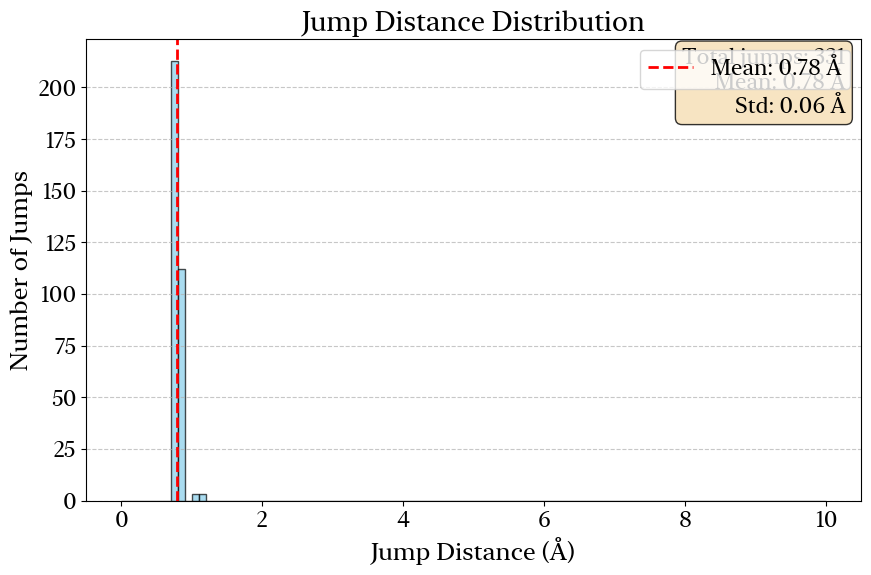

Saved analysis summary: /media/ram/ext_disk/proj_mof/dp_data/test_package/analysis_output/jump_analysis_summary.dat
✅ Jump diffusivity calculation complete with data saved


In [6]:
# %%
# --- 8. Create Diffusing Atoms Group and Run Jump Analysis ---
print("\n🔄 Creating diffusing atoms group...")
diffusing_atoms_group = sim_data_obj.universe.select_atoms(f"element {diffusing_element}")
print(f"✅ Selected {len(diffusing_atoms_group)} {diffusing_element} atoms for jump analysis")

print("\n🔄 Analyzing jumps between sites...")
jump_analysis = JumpAnalyzer(
    diffusing_atom_group=diffusing_atoms_group,
    site_coordinates_cart=discovered_sites_cart
)

# Set the maximum site radius for jump detection
jump_analysis.site_radius = max_site_radius
print(f"Setting site radius to maximum: {max_site_radius:.4f} Å")

jump_analysis.run(verbose=True)
num_jumps_found = len(jump_analysis.results.all_trans) if hasattr(jump_analysis.results, 'all_trans') else 0
print(f"✅ Jump analysis complete: {num_jumps_found} jumps detected")

# --- 9. Calculate Jump Diffusivity ---
print("\n🔄 Calculating jump diffusivity...")
jump_diffusivity_val = 0.0
if num_jumps_found > 0:
    diffusivity_analyzer = JumpDiffusivityAnalyzer(
        sim_data=sim_data_obj,
        jump_analysis_results=jump_analysis.results,
        site_coordinates_cart=discovered_sites_cart
    )
    
    jump_diffusivity_val = diffusivity_analyzer.calculate_jump_properties(
        show_plot=True,
        save_data=True,
        output_dir=output_data_path
    )
    
    diffusivity_analyzer.save_jump_summary(jump_diffusivity_val, output_data_path)
    print("✅ Jump diffusivity calculation complete with data saved")
else:
    print("⚠️ No jumps found - skipping jump diffusivity calculation")



🔄 Analyzing collective jump behavior...

--- Stage: Analyzing Collective Jumps ---
INFO: Using calculated time window for collective jumps: 4 steps.
INFO: Using spatial window for collective jumps: 6.0 Å.
Total number of jumps: 331
Number of possibly collective jump pairs found: 35
Number of jumps involved in multiple correlations: 10
✅ Collective jump analysis complete

🛤️ Analyzing comprehensive migration pathways...
🔄 Generating comprehensive migration pathway analysis...
Migration Probability Analysis:
  Total jumps: 331
  Active sites: 10/60
  Max probability: 1.0000
  Normalization: outgoing
Plotted 10 migration pathways


/media/ram/ext_disk/proj_mof/dp_data/analysis/vf_ppr/GPhIon/visualization/mig_path_plotter.py:193: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from current font.
  plt.savefig(output_file, dpi=300, bbox_inches='tight')


3D migration pathway plot saved: /media/ram/ext_disk/proj_mof/dp_data/test_package/analysis_output/3d_migration_pathways.png


/home/ram/software/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


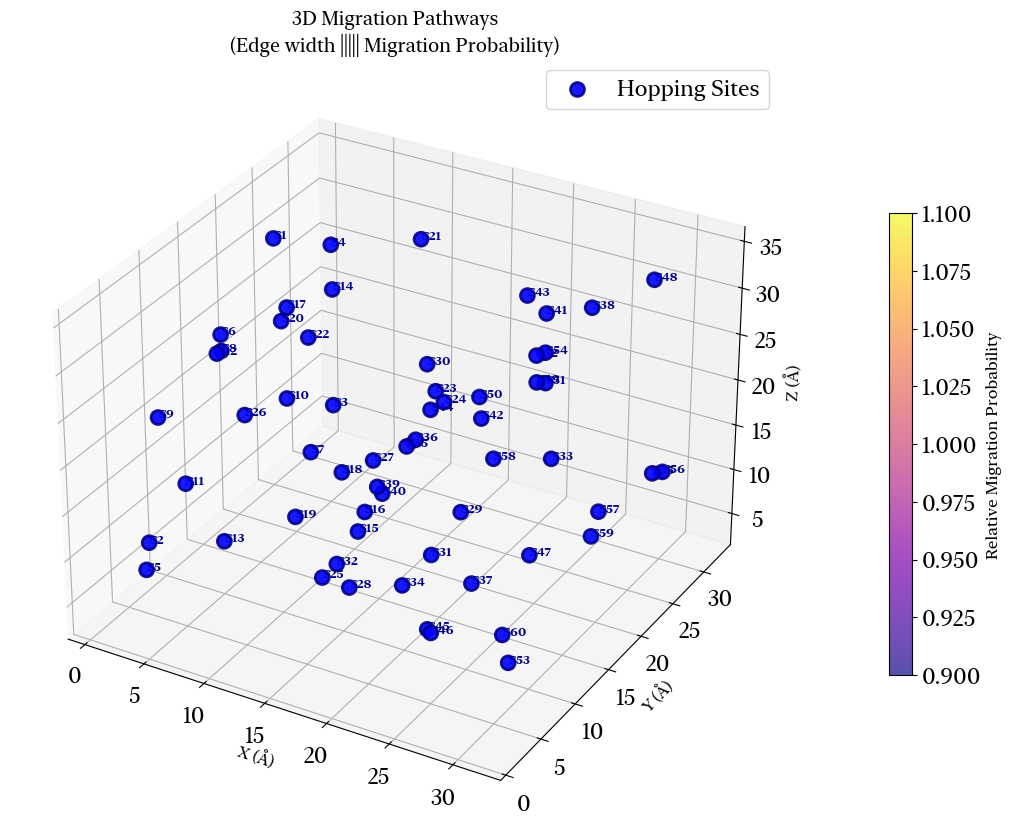

Network analysis plot saved: /media/ram/ext_disk/proj_mof/dp_data/test_package/analysis_output/migration_network.png


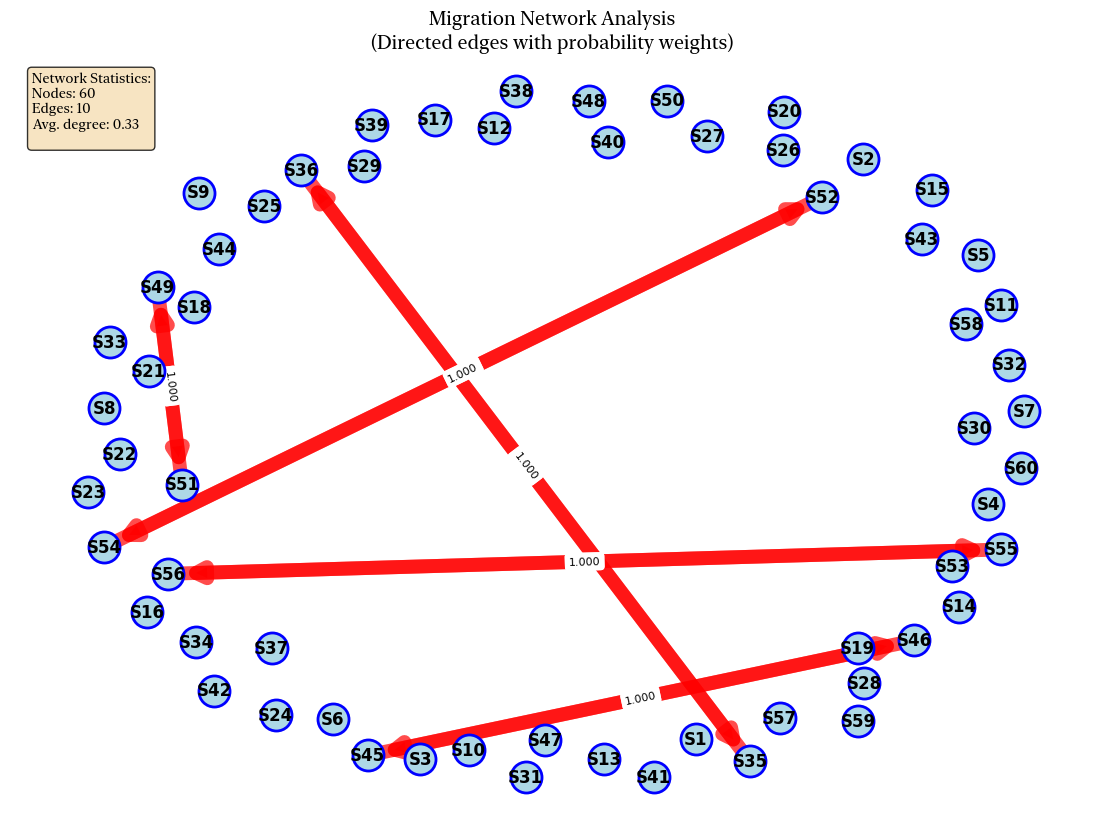


Migration Pathway Analysis:
  Active migration network: 10 sites, 10 pathways
  Most central sink (incoming): Site 35 (0.111)
  Most central source (outgoing): Site 35 (0.111)
  Most important bridge: Site 35 (0.000)
  Top migration pathways:
    1. Site 35 → Site 36: 1.0000
    2. Site 36 → Site 35: 1.0000
    3. Site 45 → Site 46: 1.0000
    4. Site 46 → Site 45: 1.0000
    5. Site 49 → Site 51: 1.0000
Migration analysis report saved: /media/ram/ext_disk/proj_mof/dp_data/test_package/analysis_output/migration_analysis_report.txt
✅ Comprehensive migration pathway analysis complete!
✅ Comprehensive migration pathway analysis complete!

🛤️ MIGRATION PATHWAY RESULTS:
 Total migration pathways: 10
 Most active source site: Site 35
 Most active sink site: Site 35
 Key bridge site: Site 35
 Highest probability pathway: Site 35 → Site 36 (1.0000)

⚡ Calculating comprehensive activation energies...

--- Activation Energy Analysis ---
Validation check:
 Effective frequency: 2.30e+09 Hz
 Attem

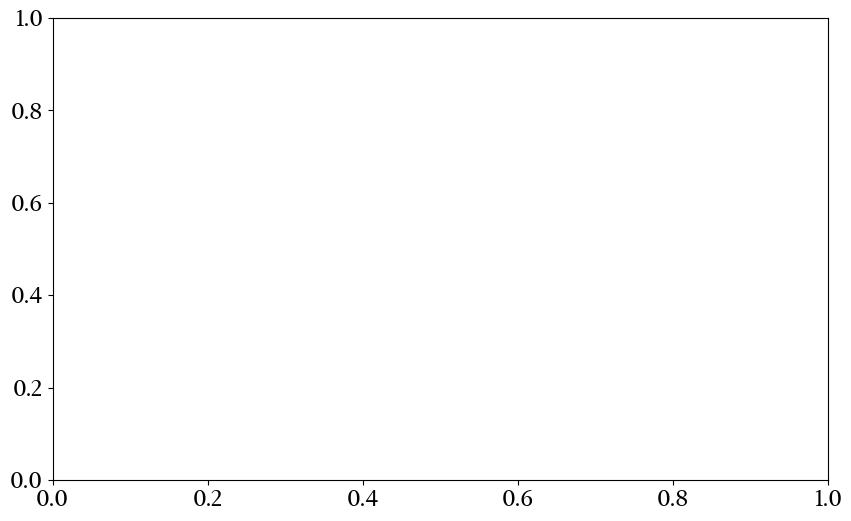

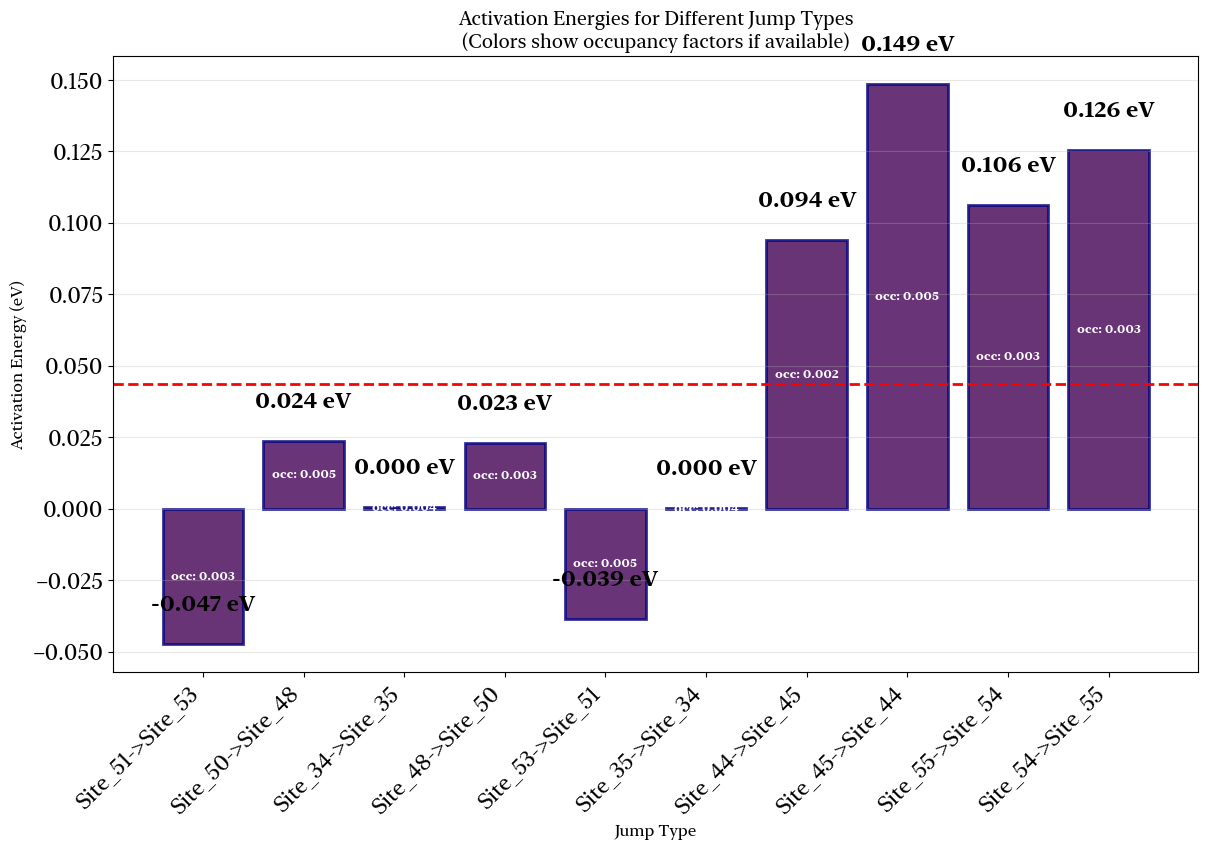

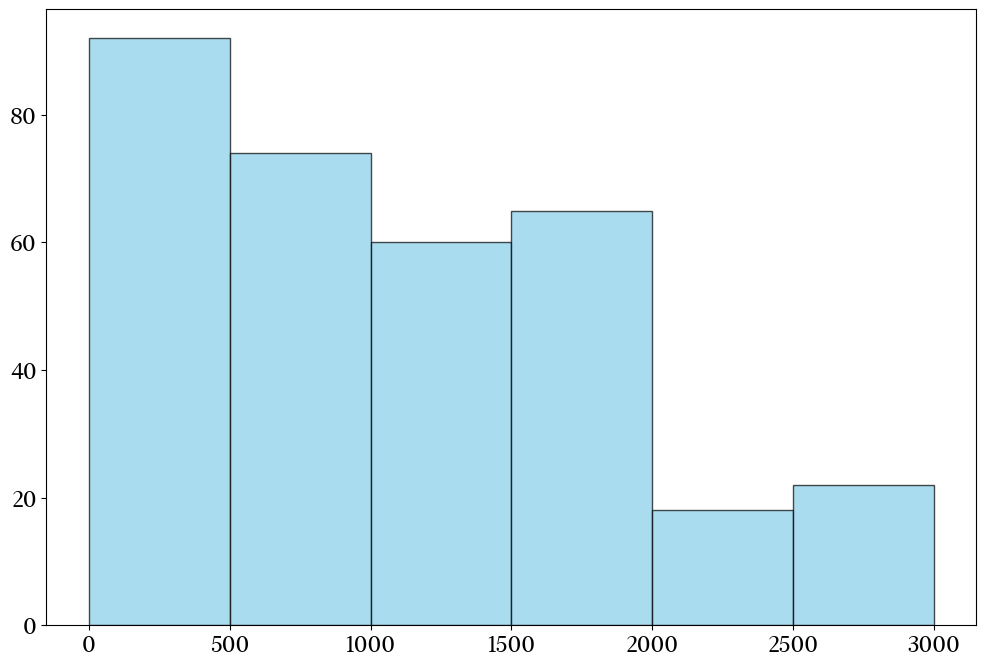

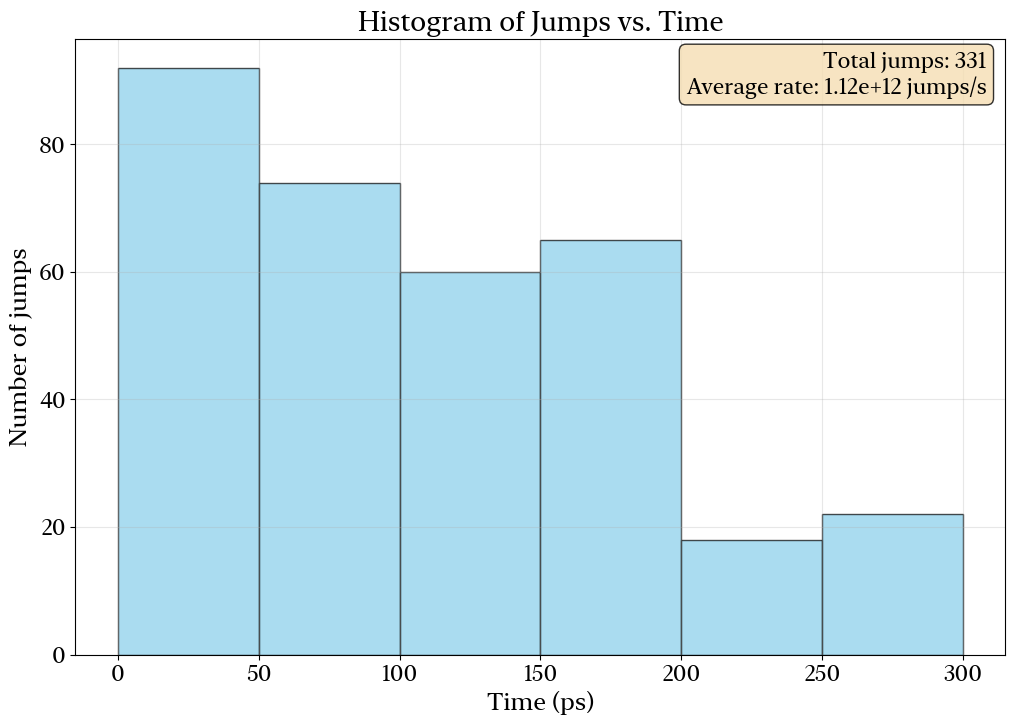

Plot saved: /media/ram/ext_disk/proj_mof/dp_data/test_package/analysis_output/collective_jump_matrix.png


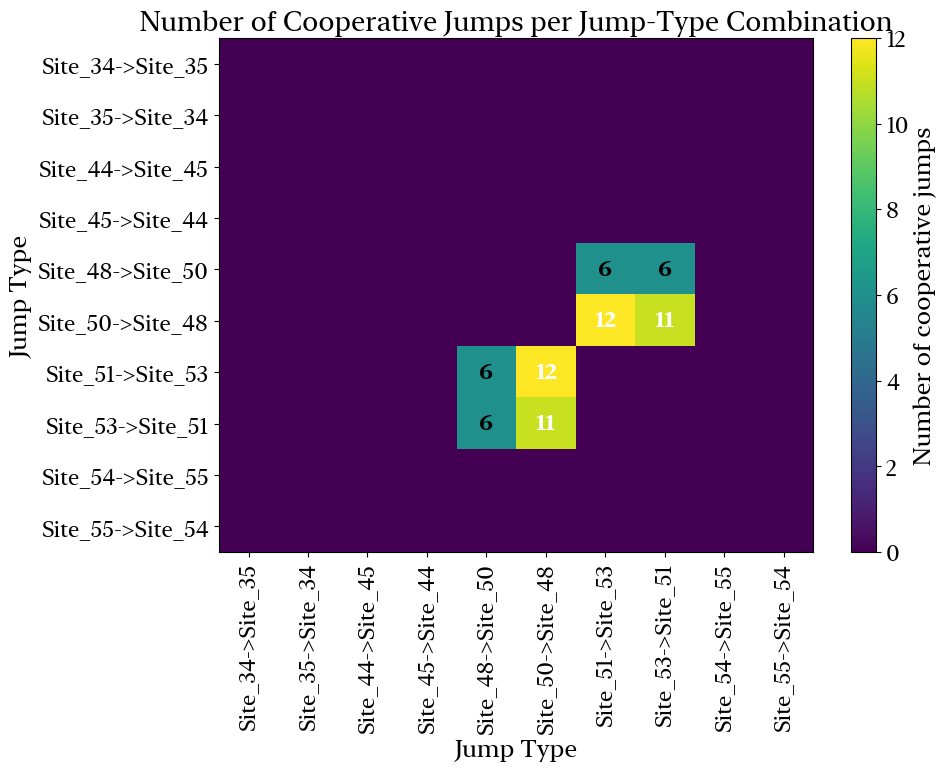

Plot saved: /media/ram/ext_disk/proj_mof/dp_data/test_package/analysis_output/collective_jump_heatmap.png


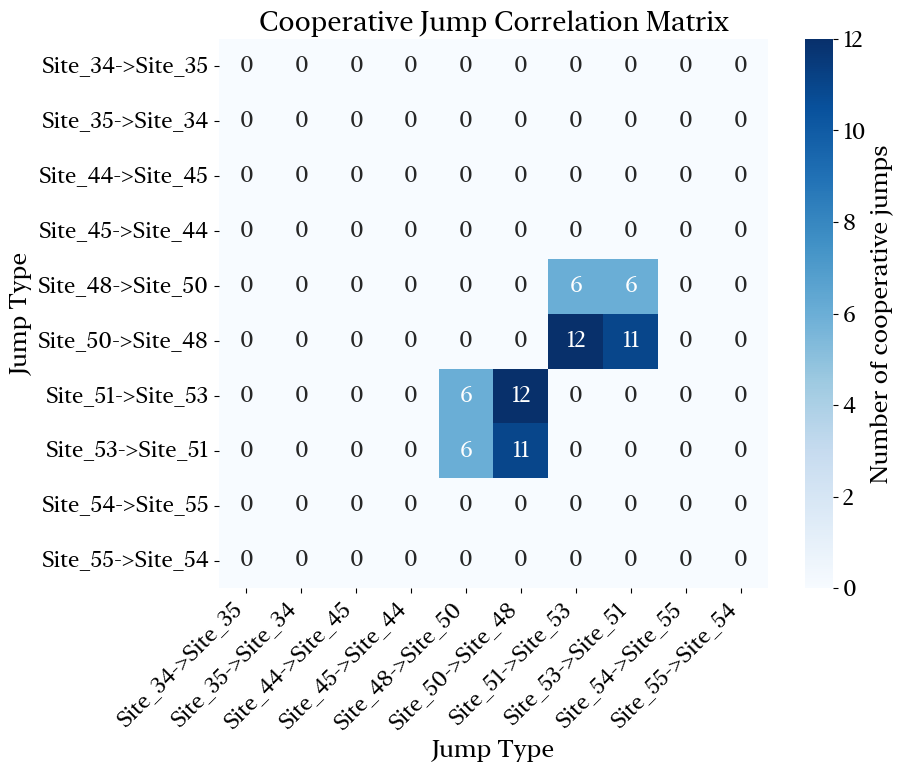

Plot saved: /media/ram/ext_disk/proj_mof/dp_data/test_package/analysis_output/collective_summary.png


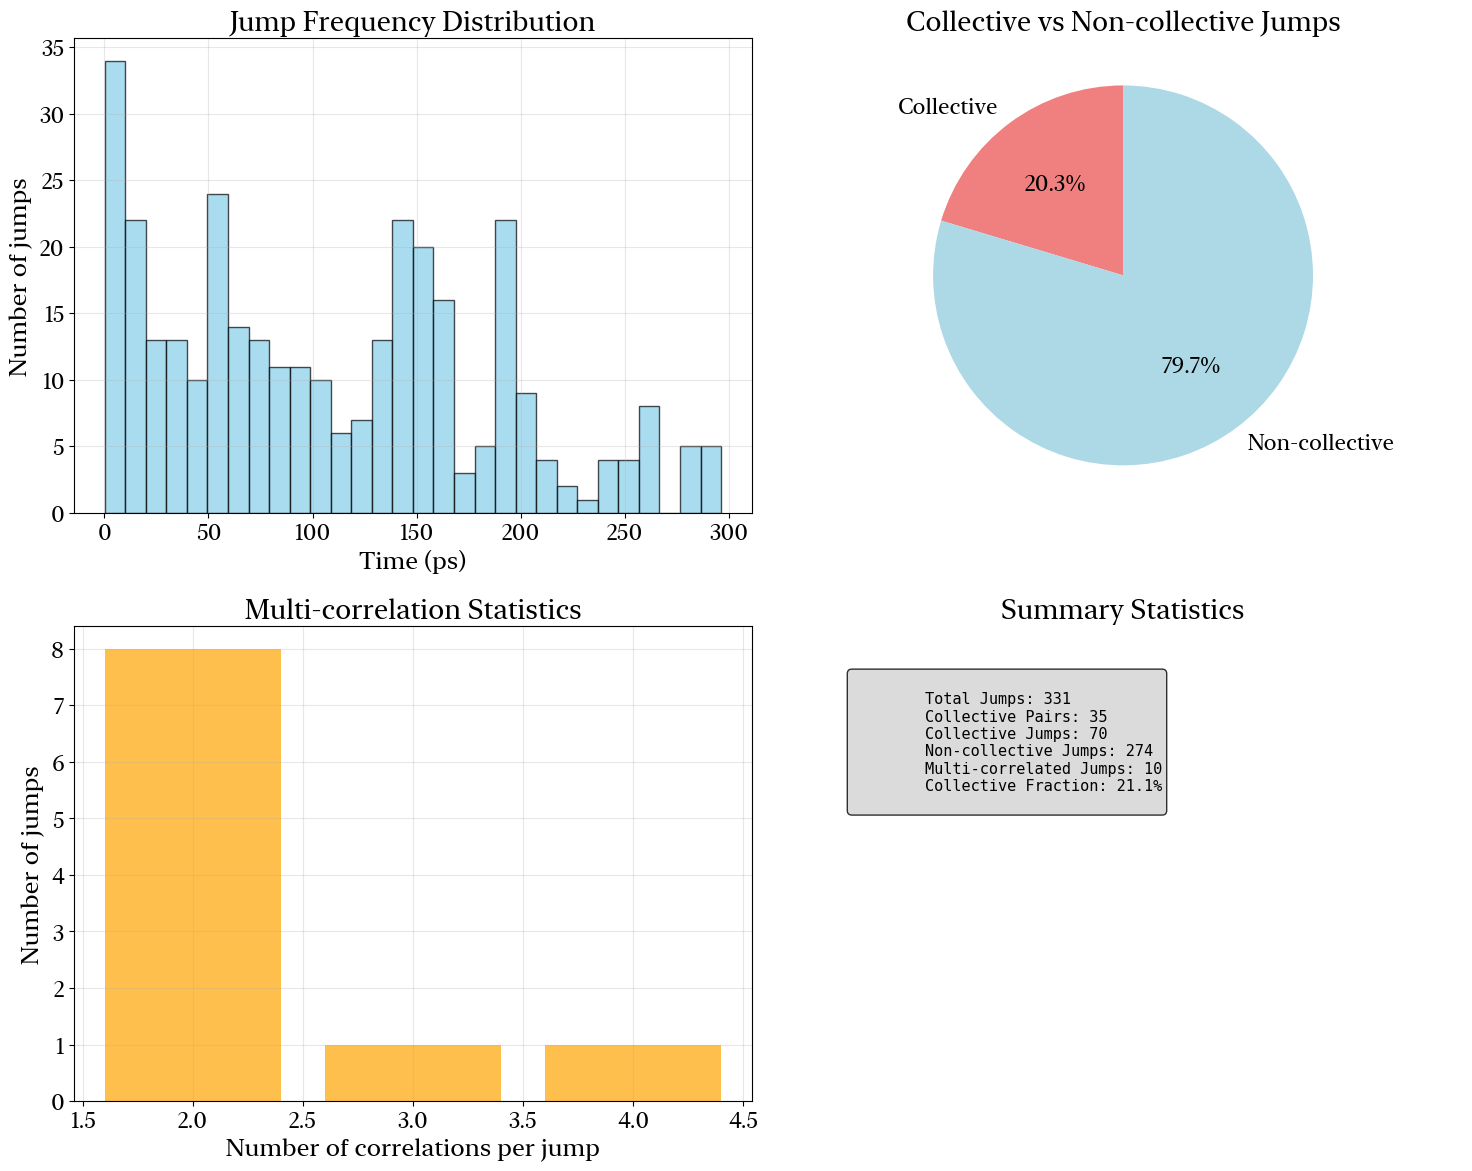

✅ All collective jump plots generated!
✅ All collective plots generated!

🔄 Running additional comprehensive analyses...


/media/ram/ext_disk/proj_mof/dp_data/analysis/vf_ppr/GPhIon/visualization/connectivity_plotter.py:132: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from current font.
  plt.savefig(output_file, dpi=300, bbox_inches='tight')


3D connectivity plot saved: /media/ram/ext_disk/proj_mof/dp_data/test_package/analysis_output/3d_site_connectivity.png


/home/ram/software/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


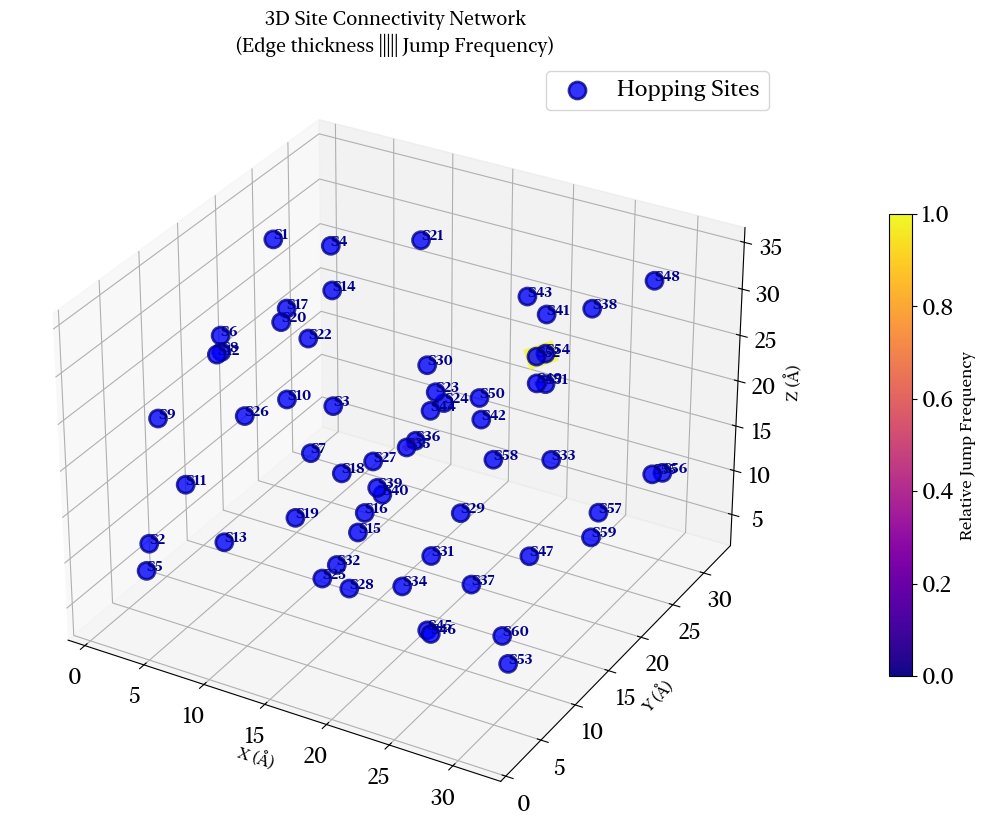

Plot saved: /media/ram/ext_disk/proj_mof/dp_data/test_package/analysis_output/individual_displacements.png


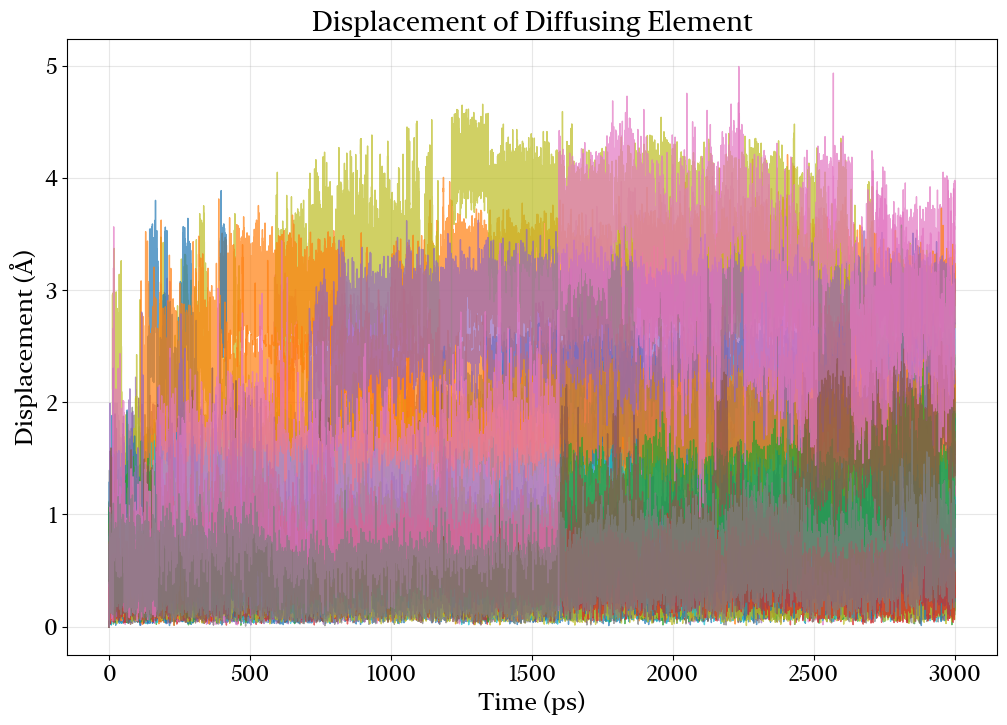

Plot saved: /media/ram/ext_disk/proj_mof/dp_data/test_package/analysis_output/displacement_histogram.png


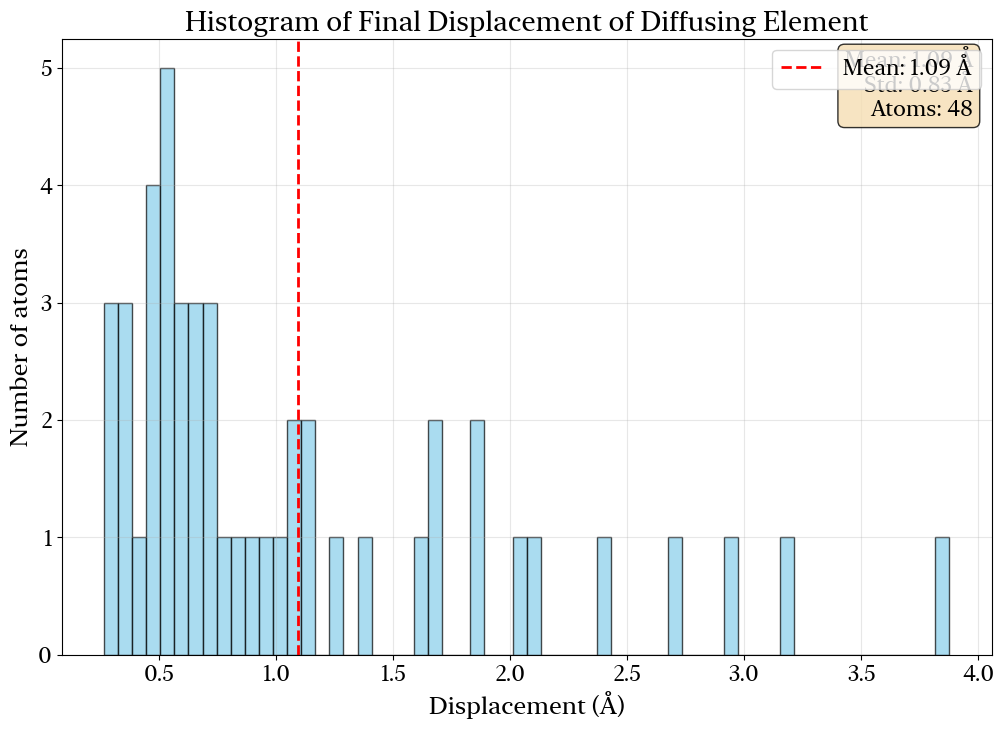

In [7]:
# --- 10. Analyze Collective Jumps ---
print("\n🔄 Analyzing collective jump behavior...")
collective_results = None
if num_jumps_found > 0:
    collective_analyzer = CollectiveJumpAnalyzer(
        sim_data=sim_data_obj,
        jump_analysis_results=jump_analysis.results,
        site_coordinates_cart=discovered_sites_cart,
        coll_dist=experimental_coll_dist,
        coll_steps_manual=experimental_coll_steps
    )
    
    collective_results = collective_analyzer.analyze()
    print("✅ Collective jump analysis complete")
else:
    print("⚠️ No jumps found - skipping collective jump analysis")

# --- 11. COMPREHENSIVE Migration Pathway Analysis ---
print("\n🛤️ Analyzing comprehensive migration pathways...")
if num_jumps_found > 0:
    migration_plotter = MigrationPathwayPlotter()
    
    # Generate all migration pathway analyses in one comprehensive call
    migration_analysis = migration_plotter.plot_comprehensive_migration_analysis(
        sites_cart=discovered_sites_cart,
        jump_data=jump_analysis.results.all_trans,
        min_probability=0.001,
        output_dir=output_data_path
    )
    
    print("✅ Comprehensive migration pathway analysis complete!")
    
    # Display key results
    prob_results = migration_analysis['migration_probabilities']
    pathway_results = migration_analysis['pathway_analysis']
    print(f"\n🛤️ MIGRATION PATHWAY RESULTS:")
    print(f" Total migration pathways: {pathway_results['total_edges']}")
    print(f" Most active source site: Site {pathway_results['most_central_out'][0]+1}")
    print(f" Most active sink site: Site {pathway_results['most_central_in'][0]+1}")
    print(f" Key bridge site: Site {pathway_results['most_between'][0]+1}")
    
    if pathway_results['high_probability_edges']:
        top_pathway = pathway_results['high_probability_edges'][0]
        print(f" Highest probability pathway: Site {top_pathway[0]+1} → Site {top_pathway[1]+1} ({top_pathway[2]:.4f})")
else:
    print("⚠️ No jumps found - skipping migration pathway analysis")

# --- 12. COMPREHENSIVE Activation Energy Analysis ---
print("\n⚡ Calculating comprehensive activation energies...")
if num_jumps_found > 0:
    sim_data_obj.temperature = temperature  # K
    activation_analyzer = ActivationEnergyAnalyzer(sim_data_obj)
    
    # Overall activation energy
    total_time = sim_data_obj.total_time
    effective_freq = num_jumps_found / (sim_data_obj.nr_diffusing * total_time)
    
    print(f"Validation check:")
    print(f" Effective frequency: {effective_freq:.2e} Hz")
    print(f" Attempt frequency: {sim_data_obj.attempt_freq:.2e} Hz")
    print(f" Frequency ratio: {effective_freq/sim_data_obj.attempt_freq:.4f}")
    
    if effective_freq/sim_data_obj.attempt_freq < 1.0:
        try:
            overall_activation = activation_analyzer.calculate_activation_energy_from_frequencies(
                effective_jump_freq=effective_freq,
                attempt_freq=sim_data_obj.attempt_freq,
                temperature=sim_data_obj.temperature
            )
            print(f"✅ Overall Activation Energy: {overall_activation['activation_energy_eV']:.3f} eV")
        except Exception as e:
            print(f"⚠️ Could not calculate overall activation energy: {e}")
    
    # Site-specific with occupancy corrections - FIXED COLORBAR ERROR
    try:
        site_energies = activation_analyzer.calculate_activation_energies_with_occupancy(
            jump_analysis_results=jump_analysis,
            sites_cart=discovered_sites_cart,
            temperature=sim_data_obj.temperature
        )
        
        if site_energies:
            # Create a figure and axes for the comparison plot to fix colorbar error
            import matplotlib.pyplot as plt
            fig, ax = plt.subplots(figsize=(10, 6))
            
            # Modified activation energy comparison with explicit axes
            activation_analyzer.compare_activation_energies(
                site_energies,
                output_file=f"{output_data_path}/activation_energies_comparison.png"
            )
            plt.close()  # Close the figure to prevent interference

            activation_analyzer.generate_activation_energy_report(
                site_energies,
                output_file=f"{output_data_path}/activation_energy_report.txt"
            )
            
            print(f"✅ Site-specific activation energies calculated for {len(site_energies)} jump types")
    except Exception as e:
        print(f"⚠️ Site-specific activation energy calculation failed: {e}")
else:
    print("⚠️ No jumps found - skipping activation energy analysis")

# %%
# --- 13. CONSOLIDATED Data Saving ---
print("\n💾 Saving all occupancy and jump data...")
jump_output_path = f"{output_data_path}/jump_output"
os.makedirs(jump_output_path, exist_ok=True)

if num_jumps_found > 0:
    # Save all data files with proper formatting
    site_occupancy_data = np.column_stack([
        np.arange(len(jump_analysis.results.site_occupancies)),
        jump_analysis.results.site_occupancies
    ])
    np.savetxt(f'{jump_output_path}/site_occupancies.txt',
               site_occupancy_data,
               header='Site_ID Average_Occupancy(atoms)',
               fmt='%d %.6f')
    
    occupancy_factor_data = np.column_stack([
        np.arange(len(jump_analysis.results.average_occupancy_factors)),
        jump_analysis.results.average_occupancy_factors
    ])
    np.savetxt(f'{jump_output_path}/occupancy_factors.txt',
               occupancy_factor_data,
               header='Site_ID Occupancy_Factor',
               fmt='%d %.6f')
    
    # Save residence time statistics
    with open(f'{jump_output_path}/residence_time_stats.txt', 'w') as f:
        f.write("Site_ID Mean_ResidenceTime(ps) Std_ResidenceTime Min_ResidenceTime Max_ResidenceTime Count\n")
        for site_idx in range(jump_analysis.n_sites):
            stats = jump_analysis.results.residence_time_stats[site_idx]
            f.write(f"{site_idx} {stats['mean']:.6f} {stats['std']:.6f} "
                   f"{stats['min']:.6f} {stats['max']:.6f} {stats['count']}\n")
    
    # Save jump events
    np.savetxt(f'{jump_output_path}/jump_events.txt', jump_analysis.results.all_trans,
               header='AtomIndex FromSite ToSite Time(ps)', fmt='%d %d %d %.6f')
    
    # Save jump-specific occupancy factors
    occupancy_factors = jump_analysis.get_jump_specific_occupancy_factors()
    with open(f'{jump_output_path}/jump_occupancy_factors.txt', 'w') as f:
        f.write("Jump_Type Occupancy_Factor\n")
        for jump_type, factor in occupancy_factors.items():
            f.write(f"{jump_type} {factor:.6f}\n")
    
    # Save comprehensive summary
    with open(f'{jump_output_path}/occupancy_summary.txt', 'w') as f:
        f.write("SITE OCCUPANCY SUMMARY\n")
        f.write("="*50 + "\n\n")
        f.write(f"Total Sites: {jump_analysis.n_sites}\n")
        f.write(f"Total Diffusing Atoms: {len(jump_analysis._ag)}\n")
        f.write(f"Total Jumps Detected: {len(jump_analysis.results.all_trans)}\n")
        f.write(f"Average Site Occupancy: {np.mean(jump_analysis.results.site_occupancies):.3f} atoms\n")
        f.write(f"Average Occupancy Factor: {np.mean(jump_analysis.results.average_occupancy_factors):.4f}\n\n")
        f.write("DETAILED SITE INFORMATION:\n")
        f.write("-" * 30 + "\n")
        f.write(f"{'Site_ID':<8} {'Avg_Occ':<10} {'Occ_Factor':<12} {'Residence_Events':<15}\n")
        f.write("-" * 50 + "\n")
        for site_idx in range(jump_analysis.n_sites):
            avg_occ = jump_analysis.results.site_occupancies[site_idx]
            occ_factor = jump_analysis.results.average_occupancy_factors[site_idx]
            res_events = jump_analysis.results.residence_time_stats[site_idx]['count']
            f.write(f"{site_idx:<8} {avg_occ:<10.3f} {occ_factor:<12.6f} {res_events:<15}\n")

print("✅ All data saved with proper formatting!")

# --- 14. CONSOLIDATED Collective Analysis Plotting ---
print("\n📊 Generating all collective analysis plots...")
if collective_results:
    coll_plotter = CollectivePlotter()
    coll_plotter.plot_all_collective_analyses(
        collective_results,
        jump_analysis.results.all_trans,
        timestep=sim_data_obj.time_step,
        output_dir=output_data_path
    )
    print("✅ All collective plots generated!")
else:
    print("⚠️ No collective results available - skipping collective plotting")

# --- 15. Additional Comprehensive Analyses ---
print("\n🔄 Running additional comprehensive analyses...")

# Connectivity Analysis
if num_jumps_found > 0:
    conn_plotter = ConnectivityPlotter()
    conn_plotter.plot_3d_site_connectivity(
        sites_cart=discovered_sites_cart,
        jump_data=jump_analysis.results.all_trans,
        min_jumps=1,
        edge_width_scale=8,
        node_size=150,
        show_site_labels=True,
        colormap='plasma',
        output_file=f"{output_data_path}/3d_site_connectivity.png"
    )

# Displacement Analysis
disp_plotter = DisplacementPlotter()
disp_plotter.plot_individual_displacements(
    sim_data_obj,
    timestep=sim_data_obj.time_step,
    max_atoms=50,
    output_file=f"{output_data_path}/individual_displacements.png"
)

disp_plotter.plot_displacement_histogram(
    sim_data_obj,
    bins=60,
    output_file=f"{output_data_path}/displacement_histogram.png"
)

Creating 3D density grid: 165 x 167 x 194
Maximum density: 706.5058023469999
Plot saved: /media/ram/ext_disk/proj_mof/dp_data/test_package/analysis_output/3d_density_with_sites.png


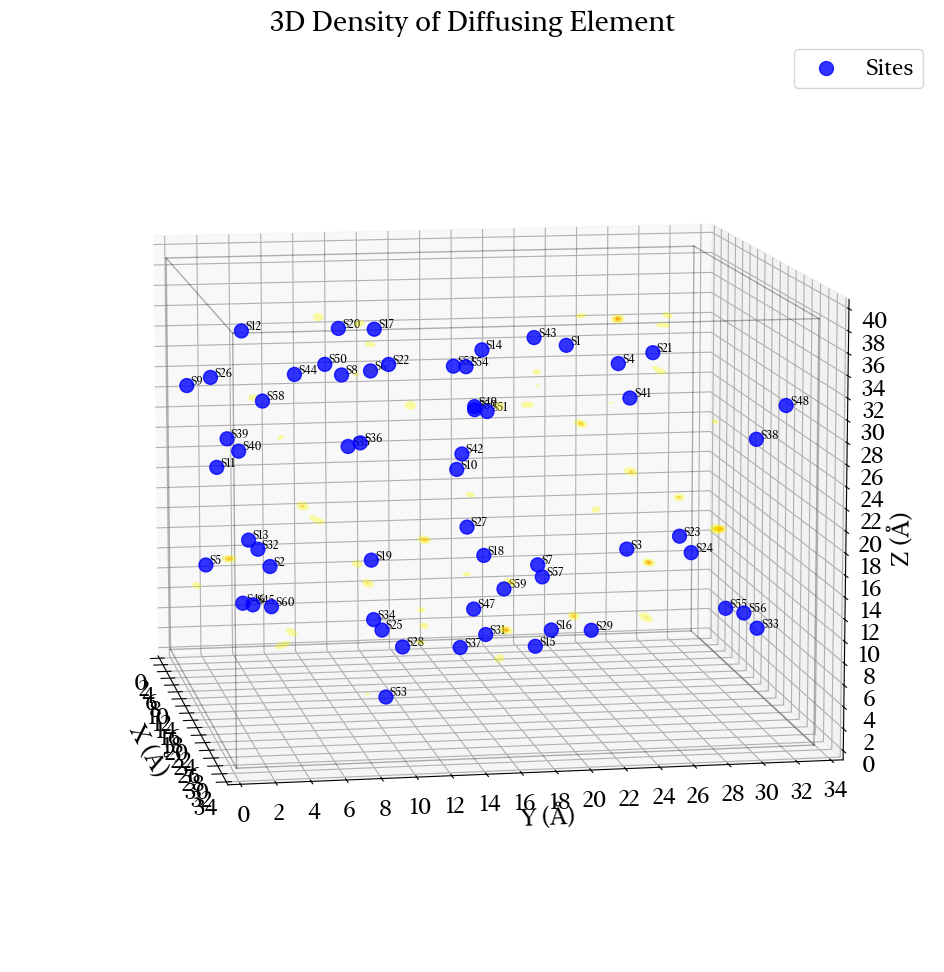

/media/ram/ext_disk/proj_mof/dp_data/analysis/vf_ppr/GPhIon/analyzers/vanhove_analyzer.py:64: UserWarning: Box is not cubic. This may affect the analysis.
  warnings.warn("Box is not cubic. This may affect the analysis.")



--- Van Hove Correlation Function Analysis ---
Analyzing 48 Li atoms
Trajectory has 30001 frames
Timestep: 0.1 fs
Box dimensions: [32.93232 33.36873 38.76633] Å
🔄 Starting complete Van Hove analysis...
Analysis parameters:
  Max r: 16.47 Å
  Bin width: 0.0082 Å
  Time lags: [10, 100, 300, 500, 700, 900]
  Valid frames for analysis: 29101
Computing self-part of van Hove function...


Self Van Hove: 100%|██████████| 29101/29101 [15:04<00:00, 32.16it/s]


Computing distinct-part of van Hove function...


Distinct Van Hove: 100%|██████████| 29101/29101 [37:20<00:00, 12.99it/s]


✅ Van Hove normalization complete
Saved: /media/ram/ext_disk/proj_mof/dp_data/test_package/analysis_output/g_self_rt.dat
Saved: /media/ram/ext_disk/proj_mof/dp_data/test_package/analysis_output/g_distinct_rt.dat
✅ Van Hove analysis complete!
Plot saved: /media/ram/ext_disk/proj_mof/dp_data/test_package/analysis_output/van_hove_self.png


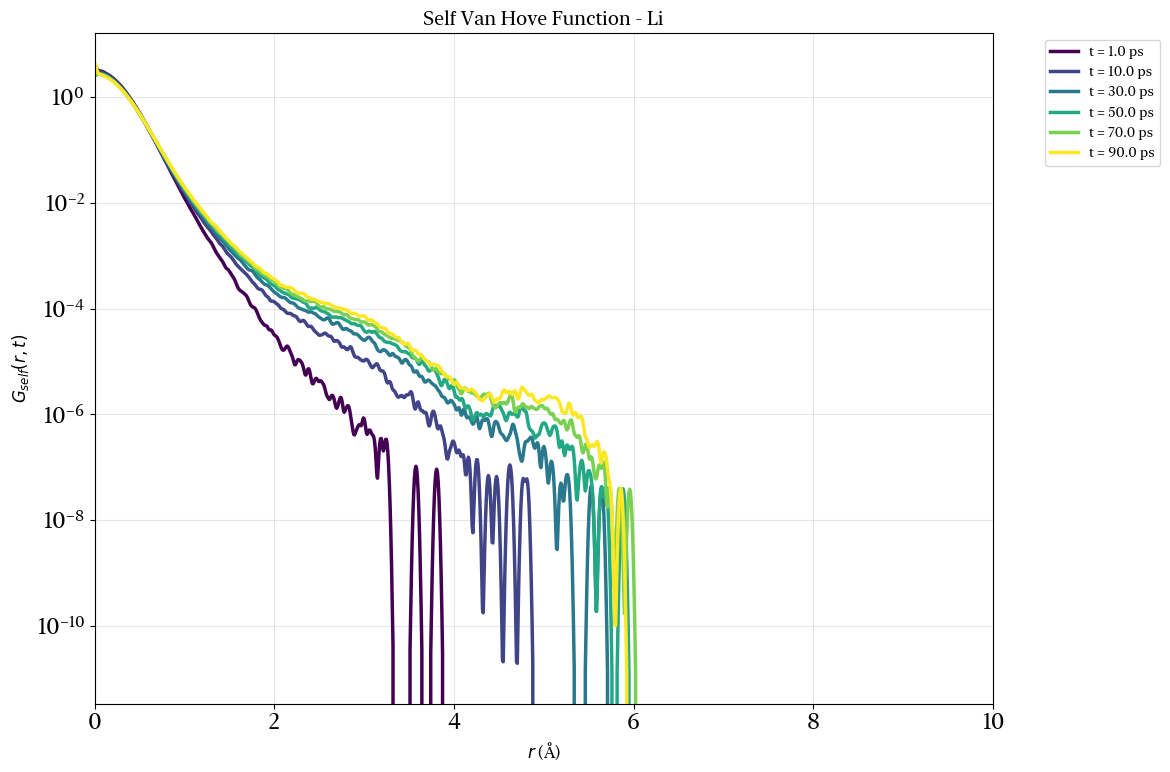

Plot saved: /media/ram/ext_disk/proj_mof/dp_data/test_package/analysis_output/van_hove_distinct.png


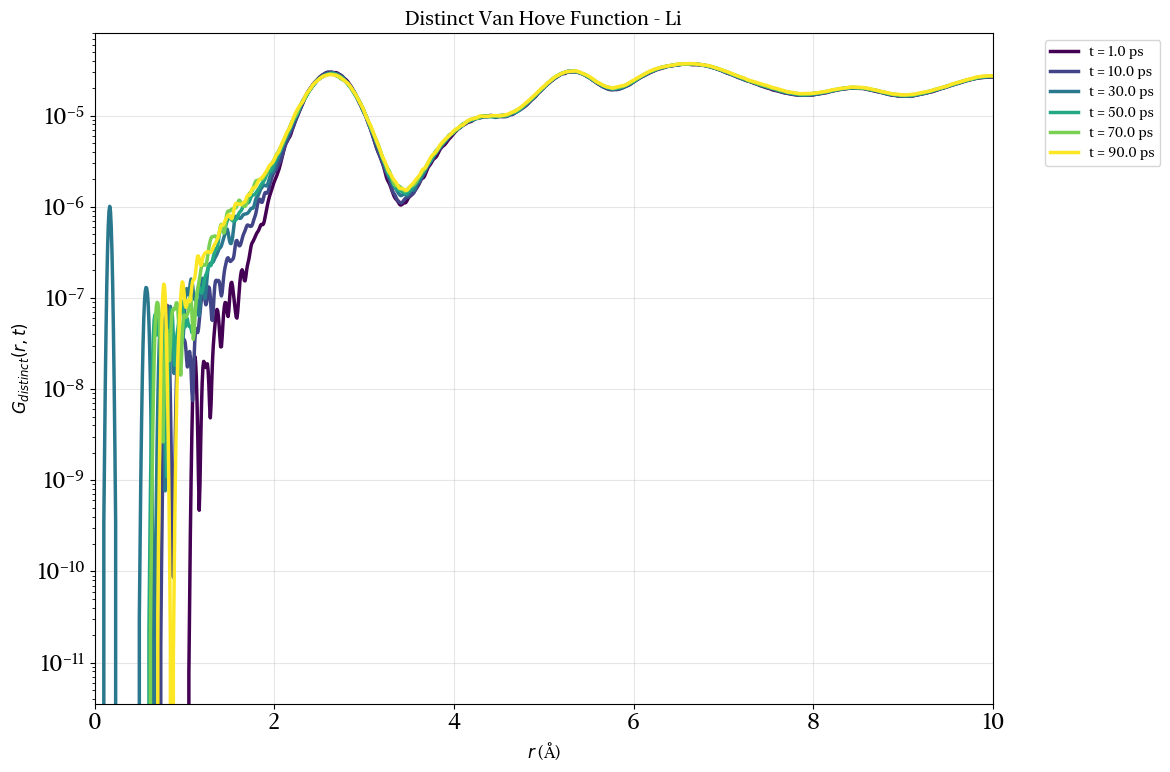

✅ All additional analyses complete!

📊 FINAL COMPREHENSIVE ANALYSIS RESULTS
📈 BASIC STATISTICS:
 Number of Jump Sites Found: 60
 Total Jumps Detected: 331
 Simulation Time: 3.00e-09 s
 Number of Frames: 30001

🔬 DIFFUSION PROPERTIES:
 Tracer Diffusivity (MSD): 1.0461e-12 m²/s
 Jump Diffusivity: 2.3576e-12 m²/s
 Particle Density: 1.1267e+27 particles/m³
 Concentration: 1.8710 mol/L

⚡ ELECTRICAL PROPERTIES:
 Tracer Conductivity: 4.8700e-03 S/m
 Ion Charge: 1.0 e
 Temperature: 450.0 K

🌊 DYNAMIC PROPERTIES:
 Jump Frequency: 3.01e+12 ± 1.3e+11 Hz
 Vibration Amplitude: 0.3434 Å
 Mean Squared Displacement: 1.8831 Å²

🤝 COLLECTIVE BEHAVIOR:
 Collective Jump Pairs: 35
 Multi-Correlated Jumps: 10
 Uncorrelated Jumps: 274
 Collective Fraction: 21.1%

📊 VAN HOVE ANALYSIS:
 Particles analyzed: 48
 Frames analyzed: 30001
 Maximum distance: 16.47 Å
 Time lags analyzed: [10, 100, 300, 500, 700, 900]

🎯 JUMP DETAILS:
 Site Radius for Jump Detection: 0.3041725754737854 Å
 Average Jumps per Atom: 6.90


UsageError: Line magic function `%%` not found.


In [8]:
disp_plotter.plot_3d_density_with_sites(
    sim_data_obj,
    sites_cart=discovered_sites_cart,
    resolution=0.2,
    iso_values=[0.8, 0.6, 0.3, 0.15, 0.05],
    colors=['red', 'orange', 'yellow'],
    alphas=[0.6, 0.4, 0.2],
    output_file=f"{output_data_path}/3d_density_with_sites.png"
)

# Van Hove Analysis
vanhove_analyzer = VanHoveAnalyzer(sim_data_obj, diffusing_element='Li')
time_lags = [10, 100, 300, 500, 700, 900]

vanhove_results = vanhove_analyzer.run_complete_analysis(
    time_lags=time_lags,
    max_r=None,
    n_bins=2000,
    output_dir=output_data_path
)

# Van Hove Plotting
vh_plotter = VanHovePlotter()
vh_plotter.plot_van_hove_functions(
    r_values=vanhove_results['r_values'],
    self_results=vanhove_results['self_normalized'],
    distinct_results=vanhove_results['distinct_normalized'],
    time_lags=vanhove_results['time_lags'],
    timestep=sim_data_obj.time_step,
    diffusing_element='Li',
    sigma=2.0,
    xlim=(0, 10),
    yscale='log',
    output_dir=output_data_path
)

print("✅ All additional analyses complete!")

# --- 16. FINAL COMPREHENSIVE RESULTS SUMMARY ---
print("\n" + "="*80)
print("📊 FINAL COMPREHENSIVE ANALYSIS RESULTS")
print("="*80)

# Basic statistics
print(f"📈 BASIC STATISTICS:")
print(f" Number of Jump Sites Found: {len(discovered_sites_cart)}")
print(f" Total Jumps Detected: {num_jumps_found}")
print(f" Simulation Time: {sim_data_obj.total_time:.2e} s")
print(f" Number of Frames: {sim_data_obj.nr_steps}")

# Diffusion properties
print(f"\n🔬 DIFFUSION PROPERTIES:")
print(f" Tracer Diffusivity (MSD): {tracer_results['tracer_diffusivity']:.4e} m²/s")
print(f" Jump Diffusivity: {jump_diffusivity_val:.4e} m²/s")
print(f" Particle Density: {tracer_results['particle_density']:.4e} particles/m³")
print(f" Concentration: {tracer_results['mol_per_liter']:.4f} mol/L")

# Electrical properties
print(f"\n⚡ ELECTRICAL PROPERTIES:")
print(f" Tracer Conductivity: {tracer_results['tracer_conductivity']:.4e} S/m")
print(f" Ion Charge: {ion_charge_z} e")
print(f" Temperature: {sim_data_obj.temperature} K")

# Dynamic properties
print(f"\n🌊 DYNAMIC PROPERTIES:")
print(f" Jump Frequency: {attempt_freq:.2e} ± {std_freq:.1e} Hz")
print(f" Vibration Amplitude: {vibration_amp:.4f} Å")
print(f" Mean Squared Displacement: {tracer_results['msd']:.4f} Å²")

# Collective behavior
print(f"\n🤝 COLLECTIVE BEHAVIOR:")
if collective_results:
    num_coll_pairs = len(collective_results.get('collective_pairs', []))
    num_multi_jumps = len(collective_results.get('multi_collective_jumps', []))
    uncoll_count = collective_results.get('uncollective_count', 0)
    print(f" Collective Jump Pairs: {num_coll_pairs}")
    print(f" Multi-Correlated Jumps: {num_multi_jumps}")
    print(f" Uncorrelated Jumps: {uncoll_count}")
    print(f" Collective Fraction: {num_coll_pairs*2/(num_jumps_found or 1):.1%}")
else:
    print(f" Collective Jump Pairs: 0 (no jumps or analysis skipped)")

# Van Hove Analysis Results
print(f"\n📊 VAN HOVE ANALYSIS:")
print(f" Particles analyzed: {vanhove_results['analysis_parameters']['n_particles']}")
print(f" Frames analyzed: {vanhove_results['analysis_parameters']['n_frames']}")
print(f" Maximum distance: {vanhove_results['analysis_parameters']['max_r']:.2f} Å")
print(f" Time lags analyzed: {vanhove_results['time_lags']}")

# Jump details
if num_jumps_found > 0:
    print(f"\n🎯 JUMP DETAILS:")
    print(f" Site Radius for Jump Detection: {getattr(jump_analysis, 'site_radius', 'N/A')} Å")
    print(f" Average Jumps per Atom: {num_jumps_found/sim_data_obj.nr_diffusing:.2f}")
    print(f" Jump Rate: {num_jumps_found/sim_data_obj.total_time:.2e} jumps/s")
    
    print(f"\n Example Jump Events (first 5):")
    print(f" {'Atom':<6} {'From':<6} {'To':<6} {'Time (ps)':<12}")
    print(f" {'-'*30}")
    for i, jump in enumerate(jump_analysis.results.all_trans[:5]):
        atom_idx, from_site, to_site, time_ps = jump
        print(f" {int(atom_idx):<6} {int(from_site):<6} {int(to_site):<6} {time_ps:<12.2f}")

# File outputs
print(f"\n📁 OUTPUT FILES GENERATED:")
print(f" Analysis Directory: {output_data_path}")
print(f" ✓ Site Coordinates: discovered_sites_cart.npy")
print(f" ✓ Site Radii: site_radii.npy")
print(f" ✓ Density Grid: occupancy_density_grid.npy")
print(f" ✓ TAOG Visualization: taog_density_plot.png")
print(f" ✓ Migration Pathways: comprehensive migration analysis")
print(f" ✓ Collective Analysis: all collective plots")
print(f" ✓ Van Hove Functions: g_self_rt.dat, g_distinct_rt.dat")
print(f" ✓ Activation Energies: activation_energies_comparison.png")
print(f" ✓ Jump Data: All occupancy and jump files in jump_output/")

print("\n✅ COMPLETE COMPREHENSIVE ANALYSIS FINISHED!")
print("="*80)

%%


# Comprehensive TAOG‐Based Jump-Diffusion Analysis Pipeline

This script performs a complete pipeline for analyzing Li-ion dynamics from molecular dynamics simulations using Time-Averaged Occupancy Grids (TAOG). The steps include:

1. **Load a LAMMPS trajectory**
2. **Compute MSD-based tracer properties**
3. **Perform full vibration analysis**
4. **Discover Li sites using TAOG**
5. **Estimate one radius per site from the TAOG density**
6. **Detect Li jumps with the estimated radius**
7. **Derive:**
   - Jump diffusivity
   - Collective behavior
   - Migration pathways
   - Activation energies
   - And more
8. **Save all intermediate datasets and plots**

In [ ]:
import os
import traceback
import numpy as np
import sys
sys.path.append('/media/ram/ext_disk/proj_mof/dp_data/analysis/vf_ppr')

# Import all components from the package
from GPhIon import (
    load_simulation_data,
    CoordinateProcessor,
    TracerPropertyAnalyzer,
    VibrationAnalyzer,
    AmorphousSiteFinder,
    SiteAnalyzerMDA,
    JumpDiffusivityAnalyzer,
    CollectiveJumpAnalyzer,
    RDFAnalyzer,
    plot_taog_density,
    VanHoveAnalyzer,
    MigrationPathwayPlotter,
    ActivationEnergyAnalyzer,
    ConnectivityPlotter,
    CollectivePlotter,
    DisplacementPlotter,
    VanHovePlotter
)

In [ ]:
print("=" * 80)
print("TAOG (Time-Averaged Occupancy Grid) Analysis")
print("=" * 80)

# ---------------------------------------------------------------------
# 1. Define Parameters
# ---------------------------------------------------------------------
project_folder            = '/media/ram/ext_disk/proj_mof/dp_data/test_package'
temperature               = 400.0  # K
dump_filename             = 'pure_400.lammpstrj'
dump_filepath             = os.path.join(project_folder, dump_filename)
# type_to_element         = {1: 'S', 2: 'F', 3: 'O', 4: 'N', 5: 'C', 6: 'Li', 7: 'Zn', 8: 'H', 9: 'Co'}
type_to_element           = {1: 'S', 2: 'F', 3: 'O', 4: 'N', 5: 'C', 6: 'Li', 7: 'Co', 8: 'H'}
timestep_ps               = 2.0      # timestep in ps => 450:0.1,  400: 2.0
diffusing_element         = 'Li'

density_grid_resolution   = 100
output_data_path          = os.path.join(project_folder, "analysis_output")
diffusion_dimensionality  = 3
ion_charge_z              = 1.0
experimental_coll_dist    = 6.0      # Å
experimental_coll_steps   = None     # let the code choose

# Ensure output directory exists
os.makedirs(output_data_path, exist_ok=True)

if not os.path.exists(dump_filepath):
    raise FileNotFoundError(f"CRITICAL ERROR: Trajectory file not found at '{dump_filepath}'")

# ---------------------------------------------------------------------
# 2. Load Trajectory Data
# ---------------------------------------------------------------------
print("\n🔄 Loading simulation data...")
sim_data_obj = load_simulation_data(
    dump_file=dump_filepath,
    type_to_element=type_to_element,
    diff_elem=diffusing_element,
    dt_ps=timestep_ps,
    temperature=temperature
)
print(f"✅ Loaded trajectory with {sim_data_obj.nr_steps} frames")
print(f" 📊 {sim_data_obj.nr_diffusing} diffusing {diffusing_element} atoms "
      f"out of {sim_data_obj.nr_atoms} total")

# ---------------------------------------------------------------------
# 3. Calculate Fractional Coordinates and Displacement
# ---------------------------------------------------------------------
print("\n🔄 Calculating coordinates and displacement...")
coord_processor = CoordinateProcessor()
sim_data_obj = coord_processor.frac_and_disp(sim_data_obj)
print("✅ Coordinate processing complete")


In [ ]:
# ---------------------------------------------------------------------
# 4. Tracer Properties (MSD)
# ---------------------------------------------------------------------
print("\n🔄 Analyzing tracer properties from MSD...")
tracer_analyzer = TracerPropertyAnalyzer(sim_data_obj)
tracer_results = tracer_analyzer.calculate_tracer_properties(
    diffusion_dim=diffusion_dimensionality,
    z_ion=ion_charge_z
)
print("✅ Tracer property analysis complete")

# ---------------------------------------------------------------------
# 5. Comprehensive Vibrational Analysis
# ---------------------------------------------------------------------
print("\n🔄 Analyzing vibrational properties...")
vib_analyzer = VibrationAnalyzer()

attempt_freq, vibration_amp, std_freq = vib_analyzer.vibration_properties(
    sim_data_obj,
    show_pics=False,
    save_data=True,
    output_dir=output_data_path
)

vib_data = vib_analyzer.get_vibration_data_only(sim_data_obj)
max_vib_amplitude = np.max(np.abs(vib_data['amplitude_data']))

# Optional custom plots
vib_analyzer.plot_amplitude_histogram_only(
    vib_data,
    bins=150,
    colors={'hist': 'skyblue', 'fit': 'darkred'},
    xlim=(-3.0, 3.0),
    output_file=f"{output_data_path}/custom_amplitude_hist.png"
)
vib_analyzer.plot_frequency_spectrum_only(
    vib_data,
    xlim=(0, 4.0e12),
    smooth_window=75,
    output_file=f"{output_data_path}/custom_frequency_spectrum.png"
)

sim_data_obj.attempt_freq       = attempt_freq
sim_data_obj.vibration_amp      = vibration_amp
sim_data_obj.std_attempt_freq   = std_freq
print("✅ Comprehensive vibrational analysis complete")

In [ ]:
# ---------------------------------------------------------------------
# 6. Site Discovery & Radius Estimation
# ---------------------------------------------------------------------
print("\n🔄 Discovering sites using TAOG method...")
site_finder = AmorphousSiteFinder(
    sim_data=sim_data_obj,
    grid_resolution=density_grid_resolution,
    save_path=output_data_path
)

# Build density grid once
density_grid, edges = site_finder._build_occupancy_grid()

# Detect peaks and obtain labels
labeled_peaks, num_features, peak_indices = site_finder._find_grid_peaks(
    density_grid, return_labels=True)

# Convert peak indices to Cartesian coordinates
discovered_sites_cart = site_finder._convert_indices_to_coords(
    peak_indices, edges)

if discovered_sites_cart.size == 0:
    raise RuntimeError("❌ No sites were discovered. Check parameters.")

# Compute site radii (95 % voxel distances + half-voxel correction)
site_radii = site_finder.get_site_radii(
    labeled_peaks, num_features, edges, discovered_sites_cart, pct=95)

max_site_radius  = site_radii.max()
mean_site_radius = site_radii.mean()

# Save site data
np.save(os.path.join(output_data_path, 'discovered_sites_cart.npy'),
        discovered_sites_cart)
np.save(os.path.join(output_data_path, 'site_radii.npy'),
        site_radii)

print(f"✅ Site discovery complete: {len(discovered_sites_cart)} sites found")
print(f" 📏 Maximum site radius: {max_site_radius:.3f} Å "
      f"(mean: {mean_site_radius:.3f} Å)")

# Optional density plot
try:
    plot_taog_density(
        density_grid, edges, threshold_ratio=0.1,
        output_file=os.path.join(output_data_path, 'taog_density_plot.png')
    )
    print("✅ TAOG density visualization saved")
except Exception as e:
    print(f"⚠️ TAOG density plot failed: {e}")

# %%
# ---------------------------------------------------------------------
# 7. Jump Analysis with Site-Based Radius
# ---------------------------------------------------------------------
print("\n🔄 Creating diffusing atoms group...")
diffusing_atoms_group = sim_data_obj.universe.select_atoms(
    f"element {diffusing_element}")
print(f"✅ Selected {len(diffusing_atoms_group)} {diffusing_element} atoms")

print("\n🔄 Detecting jumps between sites...")
jump_analysis = SiteAnalyzerMDA(
    diffusing_atom_group=diffusing_atoms_group,
    site_coordinates_cart=discovered_sites_cart
)

jump_analysis.site_radius = max_site_radius   # use most conservative value
print(f"Setting site radius to {max_site_radius:.4f} Å")
jump_analysis.run(verbose=True)

num_jumps_found = (
    len(jump_analysis.results.all_trans)
    if hasattr(jump_analysis.results, 'all_trans') else 0
)
print(f"✅ Jump analysis complete: {num_jumps_found} jumps detected")

# %%
# ---------------------------------------------------------------------
# 8. Jump Diffusivity & Collective Analysis
# ---------------------------------------------------------------------
jump_diffusivity_val = 0.0
collective_results   = None

if num_jumps_found > 0:
    # Jump diffusivity
    print("\n🔄 Calculating jump diffusivity...")
    diffusivity_analyzer = JumpDiffusivityAnalyzer(
        sim_data=sim_data_obj,
        jump_analysis_results=jump_analysis.results,
        site_coordinates_cart=discovered_sites_cart
    )
    jump_diffusivity_val = diffusivity_analyzer.calculate_jump_properties(
        show_plot=True, save_data=True, output_dir=output_data_path)
    diffusivity_analyzer.save_jump_summary(
        jump_diffusivity_val, output_data_path)
    print("✅ Jump diffusivity calculation complete")

    # Collective jumps
    print("\n🔄 Analyzing collective jump behaviour...")
    collective_analyzer = CollectiveJumpAnalyzer(
        sim_data=sim_data_obj,
        jump_analysis_results=jump_analysis.results,
        site_coordinates_cart=discovered_sites_cart,
        coll_dist=experimental_coll_dist,
        coll_steps_manual=experimental_coll_steps
    )
    collective_results = collective_analyzer.analyze()
    print("✅ Collective jump analysis complete")
else:
    print("⚠️ No jumps found – skipping diffusivity and collective analysis")

In [ ]:
# ---------------------------------------------------------------------
# 9. Migration Pathways
# ---------------------------------------------------------------------
if num_jumps_found > 0:
    print("\n🛤️ Analyzing migration pathways...")
    migration_plotter = MigrationPathwayPlotter()
    migration_plotter.plot_comprehensive_migration_analysis(
        sites_cart=discovered_sites_cart,
        jump_data=jump_analysis.results.all_trans,
        min_probability=0.001,
        output_dir=output_data_path
    )
    print("✅ Migration pathway analysis complete")
else:
    print("⚠️ No jumps found – skipping migration pathway analysis")

# %%
# ---------------------------------------------------------------------
# 10. Activation Energy Analysis
# ---------------------------------------------------------------------
if num_jumps_found > 0:
    print("\n⚡ Calculating activation energies...")
    activation_analyzer = ActivationEnergyAnalyzer(sim_data_obj)

    total_time     = sim_data_obj.total_time
    effective_freq = num_jumps_found / (sim_data_obj.nr_diffusing * total_time)

    # Overall activation energy (frequency ratio < 1 ensures ln positive)
    if effective_freq / sim_data_obj.attempt_freq < 1.0:
        overall_AE = activation_analyzer.calculate_activation_energy_from_frequencies(
            effective_jump_freq=effective_freq,
            attempt_freq=sim_data_obj.attempt_freq,
            temperature=sim_data_obj.temperature
        )
        print(f" Overall activation energy: "
              f"{overall_AE['activation_energy_eV']:.3f} eV")

    # Site specific energies with occupancy correction
    site_AEs = activation_analyzer.calculate_activation_energies_with_occupancy(
        jump_analysis_results=jump_analysis,
        sites_cart=discovered_sites_cart,
        temperature=sim_data_obj.temperature
    )
    if site_AEs:
        activation_analyzer.compare_activation_energies(
            site_AEs,
            output_file=f"{output_data_path}/activation_energies_comparison.png"
        )
        activation_analyzer.generate_activation_energy_report(
            site_AEs,
            output_file=f"{output_data_path}/activation_energy_report.txt"
        )
        print(f"✅ Site-specific activation energies calculated "
              f"for {len(site_AEs)} jump types")
else:
    print("⚠️ No jumps found – skipping activation energy analysis")

# %%
# ---------------------------------------------------------------------
# 11. Data Saving (Occupancy, Jumps, Radii …)
# ---------------------------------------------------------------------
print("\n💾 Saving occupancy and jump data...")
jump_output_path = os.path.join(output_data_path, "jump_output")
os.makedirs(jump_output_path, exist_ok=True)

# Save even if no jumps (occupancy still useful)
np.savetxt(os.path.join(jump_output_path, 'site_occupancies.txt'),
           np.column_stack([np.arange(jump_analysis.n_sites),
                            jump_analysis.results.site_occupancies]),
           header='Site_ID  Average_Occupancy(atoms)', fmt='%d %.6f')

np.savetxt(os.path.join(jump_output_path, 'occupancy_factors.txt'),
           np.column_stack([np.arange(jump_analysis.n_sites),
                            jump_analysis.results.average_occupancy_factors]),
           header='Site_ID  Occupancy_Factor', fmt='%d %.6f')

# Residence times
with open(os.path.join(jump_output_path,
                       'residence_time_stats.txt'), 'w') as f:
    f.write("Site_ID  Mean(ps)  Std  Min  Max  Count\n")
    for site_idx, stats in jump_analysis.results.residence_time_stats.items():
        f.write(f"{site_idx} {stats['mean']:.6f} {stats['std']:.6f} "
                f"{stats['min']:.6f} {stats['max']:.6f} "
                f"{stats['count']}\n")

if num_jumps_found > 0:
    # Jump events
    np.savetxt(os.path.join(jump_output_path, 'jump_events.txt'),
               jump_analysis.results.all_trans,
               header='AtomIndex  FromSite  ToSite  Time(ps)',
               fmt='%d %d %d %.6f')
    # Jump-specific occupancies
    with open(os.path.join(jump_output_path,
                           'jump_occupancy_factors.txt'), 'w') as f:
        f.write("Jump_Type  Occupancy_Factor\n")
        for jt, fac in jump_analysis.get_jump_specific_occupancy_factors().items():
            f.write(f"{jt} {fac:.6f}\n")
print("✅ All data saved")

In [ ]:
# ---------------------------------------------------------------------
# 12. Plotting (Collective, Connectivity, Displacements, Van-Hove)
# ---------------------------------------------------------------------
print("\n📊 Generating plots...")

if collective_results:
    CollectivePlotter().plot_all_collective_analyses(
        collective_results,
        jump_analysis.results.all_trans,
        timestep=sim_data_obj.time_step,
        output_dir=output_data_path
    )

if num_jumps_found > 0:
    ConnectivityPlotter().plot_3d_site_connectivity(
        sites_cart=discovered_sites_cart,
        jump_data=jump_analysis.results.all_trans,
        min_jumps=1,
        edge_width_scale=8,
        node_size=150,
        show_site_labels=True,
        colormap='plasma',
        output_file=f"{output_data_path}/3d_site_connectivity.png"
    )

# Displacements
disp_plotter = DisplacementPlotter()
disp_plotter.plot_individual_displacements(
    sim_data_obj,
    timestep=sim_data_obj.time_step,
    max_atoms=50,
    output_file=f"{output_data_path}/individual_displacements.png"
)
disp_plotter.plot_displacement_histogram(
    sim_data_obj,
    bins=60,
    output_file=f"{output_data_path}/displacement_histogram.png"
)
disp_plotter.plot_3d_density_with_sites(
    sim_data_obj,
    sites_cart=discovered_sites_cart,
    resolution=0.2,
    iso_values=[0.8, 0.6, 0.3, 0.15, 0.05],
    colors=['red', 'orange', 'yellow'],
    alphas=[0.6, 0.4, 0.2],
    output_file=f"{output_data_path}/3d_density_with_sites.png"
)

# Van-Hove
vh_analyzer = VanHoveAnalyzer(sim_data_obj, diffusing_element='Li')
time_lags = [10, 100, 300, 500, 700, 900]
vh_results = vh_analyzer.run_complete_analysis(
    time_lags=time_lags,
    max_r=None,
    n_bins=2000,
    output_dir=output_data_path
)
VanHovePlotter().plot_van_hove_functions(
    r_values=vh_results['r_values'],
    self_results=vh_results['self_normalized'],
    distinct_results=vh_results['distinct_normalized'],
    time_lags=vh_results['time_lags'],
    timestep=sim_data_obj.time_step,
    diffusing_element='Li',
    sigma=2.0,
    xlim=(0, 10),
    yscale='log',
    output_dir=output_data_path
)
print("✅ All plots generated")


In [ ]:
# ---------------------------------------------------------------------
# 13. Final Summary
# ---------------------------------------------------------------------
print("\n" + "=" * 80)
print("📊 FINAL COMPREHENSIVE ANALYSIS RESULTS")
print("=" * 80)

print(f" Number of Jump Sites Found : {len(discovered_sites_cart)}")
print(f" Total Jumps Detected       : {num_jumps_found}")
print(f" Simulation Time            : {sim_data_obj.total_time:.2e} s")
print(f" Number of Frames           : {sim_data_obj.nr_steps}")

print(f"\n🔬 DIFFUSION PROPERTIES")
print(f" Tracer Diffusivity (MSD)   : {tracer_results['tracer_diffusivity']:.4e} m^2/s")
print(f" Jump Diffusivity           : {jump_diffusivity_val:.4e} m^2/s")

print(f"\n⚡ ELECTRICAL PROPERTIES")
print(f" Tracer Conductivity        : {tracer_results['tracer_conductivity']:.4e} S/m")
print(f" Ion Charge (z)             : {ion_charge_z}")
print(f" Temperature                : {temperature} K")

print(f"\n🌊 DYNAMIC PROPERTIES")
print(f" Attempt Frequency          : {attempt_freq:.2e} ± {std_freq:.1e} Hz")
print(f" Vibration Amplitude (σ)    : {vibration_amp:.4f} Å")

if num_jumps_found > 0:
    print(f"\n🎯 JUMP DETAILS")
    print(f" Site Radius Used           : {jump_analysis.site_radius:.3f} Å")
    print(f" Avg Jumps per Atom         : {num_jumps_found / sim_data_obj.nr_diffusing:.2f}")
    print(f" Jump Rate                  : {num_jumps_found / sim_data_obj.total_time:.2e} jumps/s")

print("\n📁 All output written to:", output_data_path)
print("✅ COMPLETE COMPREHENSIVE ANALYSIS FINISHED!")
print("=" * 80)

In [ ]:
# --- 4. Calculate Tracer Properties (from MSD) ---
print("\n🔄 Analyzing tracer properties from MSD...")
tracer_analyzer = TracerPropertyAnalyzer(sim_data_obj)
tracer_results = tracer_analyzer.calculate_tracer_properties(
    diffusion_dim=diffusion_dimensionality,
    z_ion=ion_charge_z
)
print("✅ Tracer property analysis complete")

# --- 5. COMPREHENSIVE Vibrational Properties Analysis ---
print("\n🔄 Analyzing vibrational properties...")
vib_analyzer = VibrationAnalyzer()

# Run complete vibration analysis with data saving
attempt_freq, vibration_amp, std_freq = vib_analyzer.vibration_properties(
    sim_data_obj,
    show_pics=False,
    save_data=True,
    output_dir=output_data_path
)

# Get detailed vibration data
vib_data = vib_analyzer.get_vibration_data_only(sim_data_obj)
max_vib_amplitude = np.max(np.abs(vib_data['amplitude_data']))


# Generate additional custom plots
vib_analyzer.plot_amplitude_histogram_only(
    vib_data,
    bins=150,
    colors={'hist': 'skyblue', 'fit': 'darkred'},
    xlim=(-3.0, 3.0),
    output_file=f"{output_data_path}/custom_amplitude_hist.png"
)

vib_analyzer.plot_frequency_spectrum_only(
    vib_data,
    xlim=(0, 4.0e12),
    smooth_window=75,
    output_file=f"{output_data_path}/custom_frequency_spectrum.png"
)

# Store results in sim_data object
sim_data_obj.attempt_freq = attempt_freq
sim_data_obj.vibration_amp = vibration_amp
sim_data_obj.std_attempt_freq = std_freq
print("✅ Comprehensive vibrational analysis complete with all data saved")

# --- 6. Discover Sites from TAOG Density Grid ---
print("\n🔄 Discovering sites using TAOG method...")
site_finder = AmorphousSiteFinder(
    sim_data=sim_data_obj,
    grid_resolution=density_grid_resolution,
    save_path=output_data_path
)

discovered_sites_cartesian = site_finder.find_sites_from_density()
if discovered_sites_cartesian.size == 0:
    raise RuntimeError("❌ No sites were discovered. Check your parameters.")
print(f"✅ Site discovery complete: {len(discovered_sites_cartesian)} sites found")

In [ ]:
# --- 4. Site Discovery with Radius Calculation ---
print("\n🔄 Discovering sites using TAOG method...")
site_finder = AmorphousSiteFinder(
    sim_data=sim_data_obj,
    grid_resolution=density_grid_resolution,
    save_path=output_data_path
)

# Build the density grid
density_grid, edges = site_finder._build_occupancy_grid()

# Get peaks with labels
labeled_peaks, num_features, peak_indices = site_finder._find_grid_peaks(
    density_grid, return_labels=True)

# Convert to Cartesian coordinates
discovered_sites_cart = site_finder._convert_indices_to_coords(peak_indices, edges)

if discovered_sites_cart.size == 0:
    raise RuntimeError("❌ No sites were discovered. Check your parameters.")

# Calculate site radii
site_radii = site_finder.get_site_radii(
    labeled_peaks, num_features, edges, discovered_sites_cart, pct=95)

max_site_radius = site_radii.max()
mean_site_radius = site_radii.mean()

print(f"DEBUG: Site radius statistics:")
print(f"  Maximum site radius: {max_site_radius:.3f} Å")
print(f"  Mean site radius: {mean_site_radius:.3f} Å")
print(f"  Individual site radii: {site_radii}")

# Save the results
sites_filepath = os.path.join(output_data_path, 'discovered_sites_cart.npy')
radii_filepath = os.path.join(output_data_path, 'site_radii.npy')
np.save(sites_filepath, discovered_sites_cart)
np.save(radii_filepath, site_radii)

print(f"✅ Site discovery complete: {len(discovered_sites_cart)} sites found")
print(f"📏 Saved site coordinates to {sites_filepath}")
print(f"📏 Saved site radii to {radii_filepath}")

# --- 5. Create Diffusing Atoms Group for Jump Analysis ---
print("\n🔄 Creating diffusing atoms group...")
diffusing_atoms_group = sim_data_obj.universe.select_atoms(f"element {diffusing_element}")
print(f"✅ Selected {len(diffusing_atoms_group)} {diffusing_element} atoms for jump analysis")

# --- 6. Jump Analysis with Site-Based Radius ---
print("\n🔄 Analyzing jumps between sites...")
jump_analysis = SiteAnalyzerMDA(
    diffusing_atom_group=diffusing_atoms_group,
    site_coordinates_cart=discovered_sites_cart
)

# Set the maximum site radius for jump detection
jump_analysis.site_radius = max_site_radius
print(f"Setting site radius to maximum: {max_site_radius:.4f} Å")

jump_analysis.run(verbose=True)
num_jumps_found = len(jump_analysis.results.all_trans) if hasattr(jump_analysis.results, 'all_trans') else 0
print(f"✅ Jump analysis complete: {num_jumps_found} jumps detected")


In [ ]:
# --- 7. Visualize TAOG Density Grid ---
print("\n🔄 Generating TAOG density visualization...")
try:
    grid_file = os.path.join(output_data_path, 'occupancy_density_grid.npy')
    edges_file = os.path.join(output_data_path, 'occupancy_grid_edges.npy')
    
    if os.path.exists(grid_file) and os.path.exists(edges_file):
        density_grid = np.load(grid_file)
        edges = np.load(edges_file, allow_pickle=True)
        plot_output = os.path.join(output_data_path, 'taog_density_plot.png')
        plot_taog_density(density_grid, edges, threshold_ratio=0.1, output_file=plot_output)
        print("✅ TAOG visualization saved")
    else:
        print("⚠️ TAOG density files not found for visualization")
except Exception as e:
    print(f"⚠️ Could not generate TAOG visualization: {e}")
    
# --- 8. Analyze Jumps Between Discovered Sites ---
print("\n🔄 Analyzing jumps between sites...")
diffusing_atoms_group = sim_data_obj.universe.select_atoms(f"element {diffusing_element}")
jump_analysis = SiteAnalyzerMDA(
    diffusing_atom_group=diffusing_atoms_group,
    site_coordinates_cart=discovered_sites_cartesian
)
# Set custom site radius based on vibration analysis
jump_analysis.site_radius = max(max_vib_amplitude, 2.0 * vibration_amp)
print(f"Setting site radius to: {jump_analysis.site_radius:.4f} Å")
print(f"  (Based on max vib: {max_vib_amplitude:.4f} Å, mean vib: {vibration_amp:.4f} Å)")

jump_analysis.run(verbose=True)
num_jumps_found = len(jump_analysis.results.all_trans) if hasattr(jump_analysis.results, 'all_trans') else 0
print(f"✅ Jump analysis complete: {num_jumps_found} jumps detected")

# --- 9. Calculate Jump Diffusivity ---
print("\n🔄 Calculating jump diffusivity...")
jump_diffusivity_val = 0.0
if num_jumps_found > 0:
    diffusivity_analyzer = JumpDiffusivityAnalyzer(
        sim_data=sim_data_obj,
        jump_analysis_results=jump_analysis.results,
        site_coordinates_cart=discovered_sites_cartesian
    )
    
    jump_diffusivity_val = diffusivity_analyzer.calculate_jump_properties(
        show_plot=True,
        save_data=True,
        output_dir=output_data_path
    )
    
    diffusivity_analyzer.save_jump_summary(jump_diffusivity_val, output_data_path)
    print("✅ Jump diffusivity calculation complete with data saved")
else:
    print("⚠️ No jumps found - skipping jump diffusivity calculation")

# --- 10. Analyze Collective Jumps ---
print("\n🔄 Analyzing collective jump behavior...")
collective_results = None
if num_jumps_found > 0:
    collective_analyzer = CollectiveJumpAnalyzer(
        sim_data=sim_data_obj,
        jump_analysis_results=jump_analysis.results,
        site_coordinates_cart=discovered_sites_cartesian,
        coll_dist=experimental_coll_dist,
        coll_steps_manual=experimental_coll_steps
    )
    
    collective_results = collective_analyzer.analyze()
    print("✅ Collective jump analysis complete")
else:
    print("⚠️ No jumps found - skipping collective jump analysis")

# --- 11. COMPREHENSIVE Migration Pathway Analysis ---
print("\n🛤️ Analyzing comprehensive migration pathways...")
if num_jumps_found > 0:
    migration_plotter = MigrationPathwayPlotter()
    
    # Generate all migration pathway analyses in one comprehensive call
    migration_analysis = migration_plotter.plot_comprehensive_migration_analysis(
        sites_cart=discovered_sites_cartesian,
        jump_data=jump_analysis.results.all_trans,
        min_probability=0.001,
        output_dir=output_data_path
    )
    
    print("✅ Comprehensive migration pathway analysis complete!")
    
    # Display key results
    prob_results = migration_analysis['migration_probabilities']
    pathway_results = migration_analysis['pathway_analysis']
    print(f"\n🛤️ MIGRATION PATHWAY RESULTS:")
    print(f" Total migration pathways: {pathway_results['total_edges']}")
    print(f" Most active source site: Site {pathway_results['most_central_out'][0]+1}")
    print(f" Most active sink site: Site {pathway_results['most_central_in'][0]+1}")
    print(f" Key bridge site: Site {pathway_results['most_between'][0]+1}")
    
    if pathway_results['high_probability_edges']:
        top_pathway = pathway_results['high_probability_edges'][0]
        print(f" Highest probability pathway: Site {top_pathway[0]+1} → Site {top_pathway[1]+1} ({top_pathway[2]:.4f})")
else:
    print("⚠️ No jumps found - skipping migration pathway analysis")

# --- 12. COMPREHENSIVE Activation Energy Analysis ---
print("\n⚡ Calculating comprehensive activation energies...")
if num_jumps_found > 0:
    sim_data_obj.temperature = temperature  # K
    activation_analyzer = ActivationEnergyAnalyzer(sim_data_obj)
    
    # Overall activation energy
    total_time = sim_data_obj.total_time
    effective_freq = num_jumps_found / (sim_data_obj.nr_diffusing * total_time)
    
    print(f"Validation check:")
    print(f" Effective frequency: {effective_freq:.2e} Hz")
    print(f" Attempt frequency: {sim_data_obj.attempt_freq:.2e} Hz")
    print(f" Frequency ratio: {effective_freq/sim_data_obj.attempt_freq:.4f}")

    # Site-specific activation energies
    
    site_energies = activation_analyzer.calculate_site_specific_activation_energies(
        jump_data=jump_analysis.results.all_trans,
        sites_cart=discovered_sites_cartesian,
        temperature=sim_data_obj.temperature,
        attempt_freq=sim_data_obj.attempt_freq
    )
        
    if site_energies:
        activation_analyzer.compare_activation_energies(
            site_energies,
            output_file=f"{output_data_path}/activation_energies_comparison.png"
        )
    
    if effective_freq/sim_data_obj.attempt_freq < 1.0:
        try:
            overall_activation = activation_analyzer.calculate_activation_energy_from_frequencies(
                effective_jump_freq=effective_freq,
                attempt_freq=sim_data_obj.attempt_freq,
                temperature=sim_data_obj.temperature
            )
            print(f"✅ Overall Activation Energy: {overall_activation['activation_energy_eV']:.3f} eV")
        except Exception as e:
            print(f"⚠️ Could not calculate overall activation energy: {e}")
    
    # Site-specific with occupancy corrections
    try:
        site_energies = activation_analyzer.calculate_activation_energies_with_occupancy(
            jump_analysis_results=jump_analysis,
            sites_cart=discovered_sites_cartesian,
            temperature=sim_data_obj.temperature
        )
        
        if site_energies:
            activation_analyzer.compare_activation_energies(
                site_energies,
                output_file=f"{output_data_path}/activation_energies_comparison.png"
            )
            
            activation_analyzer.generate_activation_energy_report(
                site_energies,
                output_file=f"{output_data_path}/activation_energy_report.txt"
            )
            
            print(f"✅ Site-specific activation energies calculated for {len(site_energies)} jump types")
    except Exception as e:
        print(f"⚠️ Site-specific activation energy calculation failed: {e}")
else:
    print("⚠️ No jumps found - skipping activation energy analysis")


In [ ]:
# --- 13. CONSOLIDATED Data Saving ---
print("\n💾 Saving all occupancy and jump data...")
jump_output_path = f"{output_data_path}/jump_output"
os.makedirs(jump_output_path, exist_ok=True)

if num_jumps_found > 0:
    # Save all data files with proper formatting
    site_occupancy_data = np.column_stack([
        np.arange(len(jump_analysis.results.site_occupancies)),
        jump_analysis.results.site_occupancies
    ])
    np.savetxt(f'{jump_output_path}/site_occupancies.txt',
               site_occupancy_data,
               header='Site_ID Average_Occupancy(atoms)',
               fmt='%d %.6f')
    
    occupancy_factor_data = np.column_stack([
        np.arange(len(jump_analysis.results.average_occupancy_factors)),
        jump_analysis.results.average_occupancy_factors
    ])
    np.savetxt(f'{jump_output_path}/occupancy_factors.txt',
               occupancy_factor_data,
               header='Site_ID Occupancy_Factor',
               fmt='%d %.6f')
    
    # Save residence time statistics
    with open(f'{jump_output_path}/residence_time_stats.txt', 'w') as f:
        f.write("Site_ID Mean_ResidenceTime(ps) Std_ResidenceTime Min_ResidenceTime Max_ResidenceTime Count\n")
        for site_idx in range(jump_analysis.n_sites):
            stats = jump_analysis.results.residence_time_stats[site_idx]
            f.write(f"{site_idx} {stats['mean']:.6f} {stats['std']:.6f} "
                   f"{stats['min']:.6f} {stats['max']:.6f} {stats['count']}\n")
    
    # Save jump events
    np.savetxt(f'{jump_output_path}/jump_events.txt', jump_analysis.results.all_trans,
               header='AtomIndex FromSite ToSite Time(ps)', fmt='%d %d %d %.6f')
    
    # Save jump-specific occupancy factors
    occupancy_factors = jump_analysis.get_jump_specific_occupancy_factors()
    with open(f'{jump_output_path}/jump_occupancy_factors.txt', 'w') as f:
        f.write("Jump_Type Occupancy_Factor\n")
        for jump_type, factor in occupancy_factors.items():
            f.write(f"{jump_type} {factor:.6f}\n")
    
    # Save comprehensive summary
    with open(f'{jump_output_path}/occupancy_summary.txt', 'w') as f:
        f.write("SITE OCCUPANCY SUMMARY\n")
        f.write("="*50 + "\n\n")
        f.write(f"Total Sites: {jump_analysis.n_sites}\n")
        f.write(f"Total Diffusing Atoms: {len(jump_analysis._ag)}\n")
        f.write(f"Total Jumps Detected: {len(jump_analysis.results.all_trans)}\n")
        f.write(f"Average Site Occupancy: {np.mean(jump_analysis.results.site_occupancies):.3f} atoms\n")
        f.write(f"Average Occupancy Factor: {np.mean(jump_analysis.results.average_occupancy_factors):.4f}\n\n")
        f.write("DETAILED SITE INFORMATION:\n")
        f.write("-" * 30 + "\n")
        f.write(f"{'Site_ID':<8} {'Avg_Occ':<10} {'Occ_Factor':<12} {'Residence_Events':<15}\n")
        f.write("-" * 50 + "\n")
        for site_idx in range(jump_analysis.n_sites):
            avg_occ = jump_analysis.results.site_occupancies[site_idx]
            occ_factor = jump_analysis.results.average_occupancy_factors[site_idx]
            res_events = jump_analysis.results.residence_time_stats[site_idx]['count']
            f.write(f"{site_idx:<8} {avg_occ:<10.3f} {occ_factor:<12.6f} {res_events:<15}\n")

print("✅ All data saved with proper formatting!")

# --- 14. CONSOLIDATED Collective Analysis Plotting ---
print("\n📊 Generating all collective analysis plots...")
if collective_results:
    coll_plotter = CollectivePlotter()
    coll_plotter.plot_all_collective_analyses(
        collective_results,
        jump_analysis.results.all_trans,
        timestep=sim_data_obj.time_step,
        output_dir=output_data_path
    )
    print("✅ All collective plots generated!")
else:
    print("⚠️ No collective results available - skipping collective plotting")

# --- 15. Additional Comprehensive Analyses ---
print("\n🔄 Running additional comprehensive analyses...")

# Connectivity Analysis
if num_jumps_found > 0:
    conn_plotter = ConnectivityPlotter()
    conn_plotter.plot_3d_site_connectivity(
        sites_cart=discovered_sites_cartesian,
        jump_data=jump_analysis.results.all_trans,
        min_jumps=1,
        edge_width_scale=8,
        node_size=150,
        show_site_labels=True,
        colormap='plasma',
        output_file=f"{output_data_path}/3d_site_connectivity.png"
    )

# Displacement Analysis
disp_plotter = DisplacementPlotter()
disp_plotter.plot_individual_displacements(
    sim_data_obj,
    timestep=sim_data_obj.time_step,
    max_atoms=50,
    output_file=f"{output_data_path}/individual_displacements.png"
)

disp_plotter.plot_displacement_histogram(
    sim_data_obj,
    bins=60,
    output_file=f"{output_data_path}/displacement_histogram.png"
)

disp_plotter.plot_3d_density_with_sites(
    sim_data_obj,
    sites_cart=discovered_sites_cartesian,
    resolution=0.2,
    iso_values=[0.8, 0.6, 0.3, 0.15, 0.05],
    colors=['red', 'orange', 'yellow'],
    alphas=[0.6, 0.4, 0.2],
    output_file=f"{output_data_path}/3d_density_with_sites.png"
)

# Van Hove Analysis
vanhove_analyzer = VanHoveAnalyzer(sim_data_obj, diffusing_element='Li')
time_lags = [10, 100, 300, 500, 700, 900]
# time_lags = [200, 2000, 6000, 10000, 14000, 18000]        # [10, 100, 300, 500, 700, 900]

vanhove_results = vanhove_analyzer.run_complete_analysis(
    time_lags=time_lags,
    max_r=None,
    n_bins=2000,
    output_dir=output_data_path
)

# Van Hove Plotting
vh_plotter = VanHovePlotter()
vh_plotter.plot_van_hove_functions(
    r_values=vanhove_results['r_values'],
    self_results=vanhove_results['self_normalized'],
    distinct_results=vanhove_results['distinct_normalized'],
    time_lags=vanhove_results['time_lags'],
    timestep=sim_data_obj.time_step,
    diffusing_element='Li',
    sigma=2.0,
    xlim=(0, 10),
    yscale='log',
    output_dir=output_data_path
)

print("✅ All additional analyses complete!")

# --- 16. FINAL COMPREHENSIVE RESULTS SUMMARY ---
print("\n" + "="*80)
print("📊 FINAL COMPREHENSIVE ANALYSIS RESULTS")
print("="*80)

# Basic statistics
print(f"📈 BASIC STATISTICS:")
print(f" Number of Jump Sites Found: {len(discovered_sites_cartesian)}")
print(f" Total Jumps Detected: {num_jumps_found}")
print(f" Simulation Time: {sim_data_obj.total_time:.2e} s")
print(f" Number of Frames: {sim_data_obj.nr_steps}")

# Diffusion properties
print(f"\n🔬 DIFFUSION PROPERTIES:")
print(f" Tracer Diffusivity (MSD): {tracer_results['tracer_diffusivity']:.4e} m²/s")
print(f" Jump Diffusivity: {jump_diffusivity_val:.4e} m²/s")
print(f" Particle Density: {tracer_results['particle_density']:.4e} particles/m³")
print(f" Concentration: {tracer_results['mol_per_liter']:.4f} mol/L")

# Electrical properties
print(f"\n⚡ ELECTRICAL PROPERTIES:")
print(f" Tracer Conductivity: {tracer_results['tracer_conductivity']:.4e} S/m")
print(f" Ion Charge: {ion_charge_z} e")
print(f" Temperature: {sim_data_obj.temperature} K")

# Dynamic properties
print(f"\n🌊 DYNAMIC PROPERTIES:")
print(f" Jump Frequency: {attempt_freq:.2e} ± {std_freq:.1e} Hz")
print(f" Vibration Amplitude: {vibration_amp:.4f} Å")
print(f" Mean Squared Displacement: {tracer_results['msd']:.4f} Å²")

# Collective behavior
print(f"\n🤝 COLLECTIVE BEHAVIOR:")
if collective_results:
    num_coll_pairs = len(collective_results.get('collective_pairs', []))
    num_multi_jumps = len(collective_results.get('multi_collective_jumps', []))
    uncoll_count = collective_results.get('uncollective_count', 0)
    print(f" Collective Jump Pairs: {num_coll_pairs}")
    print(f" Multi-Correlated Jumps: {num_multi_jumps}")
    print(f" Uncorrelated Jumps: {uncoll_count}")
    print(f" Collective Fraction: {num_coll_pairs*2/(num_jumps_found or 1):.1%}")
else:
    print(f" Collective Jump Pairs: 0 (no jumps or analysis skipped)")

# Van Hove Analysis Results
print(f"\n📊 VAN HOVE ANALYSIS:")
print(f" Particles analyzed: {vanhove_results['analysis_parameters']['n_particles']}")
print(f" Frames analyzed: {vanhove_results['analysis_parameters']['n_frames']}")
print(f" Maximum distance: {vanhove_results['analysis_parameters']['max_r']:.2f} Å")
print(f" Time lags analyzed: {vanhove_results['time_lags']}")

# Jump details
if num_jumps_found > 0:
    print(f"\n🎯 JUMP DETAILS:")
    print(f" Site Radius for Jump Detection: {getattr(jump_analysis, 'site_radius', 'N/A')} Å")
    print(f" Average Jumps per Atom: {num_jumps_found/sim_data_obj.nr_diffusing:.2f}")
    print(f" Jump Rate: {num_jumps_found/sim_data_obj.total_time:.2e} jumps/s")
    
    print(f"\n Example Jump Events (first 5):")
    print(f" {'Atom':<6} {'From':<6} {'To':<6} {'Time (ps)':<12}")
    print(f" {'-'*30}")
    for i, jump in enumerate(jump_analysis.results.all_trans[:5]):
        atom_idx, from_site, to_site, time_ps = jump
        print(f" {int(atom_idx):<6} {int(from_site):<6} {int(to_site):<6} {time_ps:<12.2f}")

# File outputs
print(f"\n📁 OUTPUT FILES GENERATED:")
print(f" Analysis Directory: {output_data_path}")
print(f" ✓ Site Coordinates: discovered_sites_cart.npy")
print(f" ✓ Density Grid: occupancy_density_grid.npy")
print(f" ✓ TAOG Visualization: taog_density_plot.png")
print(f" ✓ Migration Pathways: comprehensive migration analysis")
print(f" ✓ Collective Analysis: all collective plots")
print(f" ✓ Van Hove Functions: g_self_rt.dat, g_distinct_rt.dat")
print(f" ✓ Activation Energies: activation_energies_comparison.png")
print(f" ✓ Jump Data: All occupancy and jump files in jump_output/")

print("\n✅ COMPLETE COMPREHENSIVE ANALYSIS FINISHED!")
print("="*80)